In [198]:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vivianemattos/mvp-vmm-analise-dados-boas-praticas/blob/main/MVP_Analise_Dados_Boas_Praticas_VivianeMMatos.ipynb)

SyntaxError: invalid syntax (ipython-input-198-1431735555.py, line 1)

# MVP Análise de Dados e Boas Práticas

**Nome:** Viviane Mendes Matos

**Matrícula:** 4052025000007

**Dataset:** [Disney+ Dataset from Kaggle](https://raw.githubusercontent.com/vivianemattos/mvp-vmm-analise-dados-boas-praticas/refs/heads/main/disney_plus_titles_w43.csv)


# 1. Descrição do Problema

O Disney+ é uma das plataformas de streaming mais populares disponíveis atualmente e como referência em 2021 contava com cerca de 116 milhões de assinantes em todo o mundo.  O conjunto de dados Filmes Disney+ é multivariado e contém uma lista de 1450 filmes e shows detalhando elenco, diretores, classificações, ano de lançamento, duração, etc.  

O objetivo principal deste projeto é explorar e analisar o catálogo de títulos Disney+ para avaliar padrões de conteúdo e posteriormente viabilizar recomendações de títulos, análises de preferências de usuário e tendências de produção.

## 1.1 Hipóteses do Problema

O objetivo é responder perguntas como:

- Quanto tempo em média um conteúdo demora para entrar na plataforma de streaming Disney+?

- Quais classificações etárias são mais frequentes?

- Existe variação em relação aos gêneros de filmes lançados ao longo dos anos?

- Qual o principal perfil do conteúdo disponibilizado no Disney+?

## 1.2 Tipo de Problema

Neste momento, o objetivo é ser um projeto mais descritivo e focado em análise exploratória, ou seja, **classificação não supervisionada**.  Futuramente poderá apoiar tarefas supervisionadas como por exemplo, classificação de tipo de conteúdo, recomendação de títulos, sugestão de curadoria e tendências de produção.

## 1.3 Seleção de Dados

O dataset Disney+ é um conjunto de dados obtido na plataforma Kaggle e corresponde a todos os títulos disponíveis até a data da extração.  Não há filtros prévios aplicados ao conteúdo.

## 1.4 Atributos do Dataset

O dataset Disney+ contém 1540 amostras, divididas em 1052 filmes e 398 séries. Possui 12 atributos:

- ***show_id*** (identificador do conteúdo)
- ***type*** (formato de conteúdo)
- ***title*** (título do conteúdo)
- ***director*** (diretor do conteúdo)
- ***cast*** (elenco principal do conteúdo)
- ***country*** (país de origem do conteúdo)
- ***date_added*** (data em que o conteúdo foi incluído na plataforma)
- ***release_year*** (ano em que o conteúdo foi lançado)
- ***rating*** (classificação etária do conteúdo)
- ***duration*** (duração do conteúdo - pode ser expressa em minutos ou temporadas)
- ***listed_in*** (classificação de categorias do conteúdo)
- ***description*** (descrição curta a respeito do conteúdo)



Em uma fase posterior, estes atributos serão traduzidos para português para melhor compreensão e tratamento.

# 2. Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Disney+.

## 2.1 Importação de Bibliotecas

In [139]:
#Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np
import ast
from scipy.stats import zscore

#Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mode
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex

#Bibliotecas para pré-processamento e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MultiLabelBinarizer

## 2.2 Carga do Dataset e atribuição do Dataframe

In [140]:
#Importando Dataset Disney+ obtido no Kaggle e disponível para este projeto no GitHub

#url a importar
url_dados ='https://raw.githubusercontent.com/vivianemattos/mvp-vmm-analise-dados-boas-praticas/main/disney_plus_titles_w43.csv'

#labels dos atributos do dataset
labels_atributos = ['show_id','type','title','director','cast','country','date_added','release_year','rating','duration','listed_in','description']

#Carregando o dataset através da url
disney = pd.read_csv(url_dados, names=labels_atributos)

#Guardando o dataset em um dataframe
df = disney

#Removendo a primeira linha (cabeçalho) para que não interfira nos gráficos
df = df.iloc[1:].reset_index(drop=True)

## 2.3 Definição de paleta de cores personalizada Disney+

In [141]:
#Definindo paleta de cores personalizada Disney+
# As primeiras três cores correspondem ao logotipo atual e as três cores seguintes correspondem ao logotipo adotado até abril-2025 antes da incorporação do conteúdo do Hulu
custom_palette = ['#081e2b', '#1f6c7d', '#3cb0bc', '#113CCF', '#BFF5FD', '#FFFFFF']
sns.set_palette(sns.color_palette(custom_palette))
sns.set_style("whitegrid")

## 2.4 Tradução das Colunas


In [142]:
#Dicionário de tradução das colunas
colunas_traduzidas = {
    'show_id': 'id_titulo',
    'type': 'tipo',
    'title': 'titulo',
    'director': 'diretor',
    'cast': 'elenco',
    'country': 'pais',
    'date_added': 'data_adicionado',
    'release_year': 'ano_lancamento',
    'rating': 'classificacao',
    'duration': 'duracao',
    'listed_in': 'generos',
    'description': 'descricao'
}

# Renomear colunas
df.rename(columns=colunas_traduzidas, inplace=True)

Para facilitar a compreensão das análises e o tratamento dos dados, as colunas foram traduzidas para o idioma português(BR) mantendo as letras em minúsculo e seus mneumônicos.

## 2.5 Exibição das primeiras linhas do dataset carregado

In [143]:
#Exibindo as primeiras linhas
df.head()

,id_titulo,tipo,titulo,diretor,elenco,pais,data_adicionado,ano_lancamento,classificacao,duracao,generos,descricao
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


# 3. Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Disney+, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

O objetivo é compreender o comportamento dos dados — incluindo a distribuição dos valores, presença de inconsistências, outliers e dados ausentes — para identificar padrões e possíveis preparações antes de aplicar modelos de aprendizado de máquina.

## 3.1 Total e Tipo das Instâncias

O dataset Disney+ possui 1450 instâncias (observações), com 1052 filmes e 398 séries. As 12 colunas são do tipo categórico (object).

In [144]:
#Exibindo o total e o tipo das instâncias

print(f"O dataset possui {df.shape[0]} instâncias (linhas) e {df.shape[1]} atributos (colunas).")

#print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

O dataset possui 1450 instâncias (linhas) e 12 atributos (colunas).

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_titulo        1450 non-null   object
 1   tipo             1450 non-null   object
 2   titulo           1450 non-null   object
 3   diretor          977 non-null    object
 4   elenco           1260 non-null   object
 5   pais             1231 non-null   object
 6   data_adicionado  1447 non-null   object
 7   ano_lancamento   1450 non-null   object
 8   classificacao    1447 non-null   object
 9   duracao          1450 non-null   object
 10  generos          1450 non-null   object
 11  descricao        1450 non-null   object
dtypes: object(12)
memory usage: 136.1+ KB
None


## 3.2 Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

## 3.2.1 Verificação das primeiras linhas do dataset para análise preliminar e primeiras impressões

In [145]:
#Exibindo as primeiras linhas do dataset para análise preliminar
df.head()

,id_titulo,tipo,titulo,diretor,elenco,pais,data_adicionado,ano_lancamento,classificacao,duracao,generos,descricao
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


O objetivo é verificar o conteúdo das primeiras linhas do dataset buscando compreender como estão preenchidas as informações.

Observa-se que há valores faltantes nos campos *'diretor'* e *'país'*.  Também observa-se que os campos *'elenco'* e *'generos'* são multivalorados.  Já o campo *'duracao'* possui texto associado e padrões de preenchimento diferentes: com filmes expressos em minutos (min) e séries expressas em temporadas (season), o que exigirá extração numérica para uma melhor avaliação.

## 3.2.2 Verificação de Valores faltantes, discrepantes ou inconsistentes



### 3.2.2.1 Verificação de Valores Faltantes

In [146]:
#Resumo dos dados com verificacao de valores faltantes de forma tabular

resumo = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Não Nulos': df.notnull().sum(),
    'Valores Nulos': df.isnull().sum()
})

print(resumo)

                Tipo de Dado  Valores Não Nulos  Valores Nulos
id_titulo             object               1450              0
tipo                  object               1450              0
titulo                object               1450              0
diretor               object                977            473
elenco                object               1260            190
pais                  object               1231            219
data_adicionado       object               1447              3
ano_lancamento        object               1450              0
classificacao         object               1447              3
duracao               object               1450              0
generos               object               1450              0
descricao             object               1450              0


Em relação aos valores faltantes, foi confirmado o que foi observado inicialmente: há 473 valores faltantes no campo '*diretor*', 190 valores faltantes no campo '*elenco*', 219 valores faltantes no campo '*país*', 3 valores faltantes no campo '*data_adicionado*' e 3 valores faltantes no campo '*classificacao*'.

### 3.2.2.2 Verificação de Valores Discrepantes

No dataset original não é possível observar valores discrepantes porque todos os campos estão com formato do tipo objeto, não permitindo este tipo de análise inicial.  Posteriormente será criada uma cópia deste dataset apontando para algumas transformações de tipos de dados onde será possível fazer essa avaliação.

## 3.2.3 Resumo Estatístico Descritivo

Através do Resumo Estatístico Descritivo é possível organizar e descrever os dados através de tabelas e gráficos para melhor compreensão.

In [147]:
#Exibindo as estatísticas descritivas básicas do dataset
df.describe()

,id_titulo,tipo,titulo,diretor,elenco,pais,data_adicionado,ano_lancamento,classificacao,duracao,generos,descricao
count,1450,1450,1450,977,1260,1231,1447,1450,1447,1450,1450,1450
unique,1450,2,1450,609,1193,89,167,90,9,158,329,1448
top,s1450,Movie,Captain Sparky vs. The Flying Saucers,Jack Hannah,Winston Hibler,United States,"November 12, 2019",2021,TV-G,1 Season,"Animation, Comedy, Family","Cooper and Cami Wrather co-host ""Would You Wra..."
freq,1,1052,1,17,10,1005,722,125,318,219,124,2


Para este dataset, todas as colunas estão originalmente como tipo categórico (object), dessa forma, não é possível calcular diretamente as médias, medianas, moda, desvio padrão, mínimo e máximo.  Para que seja possível analisar as estatísticas, será necessário fazer a conversão adequada de tipos para os campos que serão objetos principais da análise.

In [148]:
#Convertendo campos de duração para tipo numérico e criando campo adicional "ano_lancamento" para simplificar comparações anuais

df_convertido = df.copy()
df_convertido['data_adicionado'] = pd.to_datetime(df_convertido['data_adicionado'], errors='coerce')
df_convertido['ano_adicionado'] = df_convertido['data_adicionado'].dt.year.astype('Int64')
df_convertido['ano_lancamento'] = pd.to_numeric(df_convertido['ano_lancamento'], errors='coerce').astype('Int64')

print("Tipo do campo data_adicionado:", df_convertido['data_adicionado'].dtype)
print("Tipo do campo ano_adicionado:", df_convertido['ano_adicionado'].dtype)
print("Tipo do campo ano_lancamento:", df_convertido['ano_lancamento'].dtype)

df_convertido['ano_adicionado'].head()

Tipo do campo data_adicionado: datetime64[ns]
Tipo do campo ano_adicionado: Int64
Tipo do campo ano_lancamento: Int64


,ano_adicionado
0,2021
1,2021
2,2021
3,2021
4,2021


In [149]:
#Criando campo adicional para separar a duração do conteúdo e a unidade de medida e assim converter a duração para número
df_convertido['duracao_qtd'] = df_convertido['duracao'].str.extract('(\d+)').astype(int)
df_convertido['unidade_duracao'] = df_convertido['duracao'].str.extract('([a-zA-Z]+)').astype(str)

#Convertendo campo duracao_qtd para tipo numérico
df_convertido['duracao_qtd'] = pd.to_numeric(df_convertido['duracao_qtd'], errors='coerce')

print("Tipo do campo duracao_qtd: ",df_convertido['duracao_qtd'].dtype)
print("Tipo do campo unidade_duracao: ",df_convertido['unidade_duracao'].dtype)

print ("Tipo do campo ano_lancamento: ",df_convertido['ano_lancamento'].dtype)
print ("Tipo do campo ano_adicionado: ",df_convertido['ano_adicionado'].dtype)

Tipo do campo duracao_qtd:  int64
Tipo do campo unidade_duracao:  object
Tipo do campo ano_lancamento:  Int64
Tipo do campo ano_adicionado:  Int64


Foi criada uma cópia do dataset original *df* para o *df_convertido* e realizado um processo de conversão dos campos:

*   ***duracao*** --> Continha uma parte numérica e outra textual que foi desmembrada em dois campos *duracao_qtd* convertido para *integer* e *unidade_duracao* convertido para *texto*
*   ***ano_lancamento*** --> convertido para tipo *integer*
*   ***ano_adicionado*** --> Derivado a partir do campo *data_adicionado* mas contendo apenas o trecho referente ao ano de adição na plataforma, também convertido para tipo *integer*




In [150]:
# Estatísticas Descritivas Numéricas Pós-conversão

#Identifica quais colunas do dataset são de tipo numérico e cria um novo repositório temporário
colunas_numericas = df_convertido.select_dtypes(include=['int64','float64','datetime']).columns

# Cria um dicionário para armazenar as estatísticas
estatisticas = {
    'Estatística': ['Mínimo', 'Máximo', 'Mediana', 'Moda', 'Média', 'Desvio-padrão', 'Valores Ausentes']
}

# Preenche o dicionário com os dados de cada coluna
for coluna in colunas_numericas:
    try:
        moda_valor = df_convertido[coluna].mode().values[0]
    except:
        moda_valor = None

    estatisticas[coluna] = [
        df_convertido[coluna].min(),
        df_convertido[coluna].max(),
        df_convertido[coluna].median() if pd.api.types.is_numeric_dtype(df_convertido[coluna]) else None,
        moda_valor,
        df_convertido[coluna].mean() if pd.api.types.is_numeric_dtype(df_convertido[coluna]) else None,
        df_convertido[coluna].std() if pd.api.types.is_numeric_dtype(df_convertido[coluna]) else None,
        df_convertido[coluna].isnull().sum()
    ]

# Converte o dicionário em DataFrame
df_estatisticas = pd.DataFrame(estatisticas)

# Exibe a tabela
df_estatisticas

,Estatística,data_adicionado,ano_lancamento,ano_adicionado,duracao_qtd
0,Mínimo,2019-10-01 00:00:00,1928.000000,2019.000000,1.000000
1,Máximo,2021-11-26 00:00:00,2021.000000,2021.000000,183.000000
2,Mediana,None,2011.000000,2019.000000,46.000000
3,Moda,2019-11-12T00:00:00.000000000,2021.000000,2019.000000,1.000000
4,Média,None,2003.091724,2019.699378,52.753793
5,Desvio-padrão,None,21.860162,0.816594,46.557763
6,Valores Ausentes,3,0.000000,3.000000,0.000000


### 3.2.3.1 Análise Estatística Descritiva em relação aos Tipos de Conteúdos

Avaliamos os tipos de conteúdos disponíveis na plataforma.

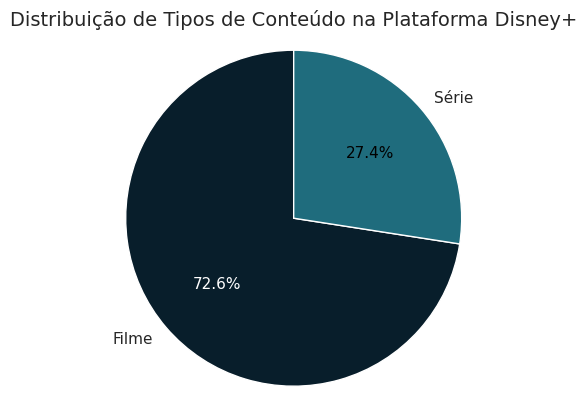

In [151]:
#Gráfico de pizza - Tipos de Conteúdo no Disney+

#Agrupa os dados pela coluna 'type'
contagem = df['tipo'].value_counts()

#Dicionário de traduções
traducoes = {
    'Movie': 'Filme',
    'TV Show': 'Série'
}

#Aplica traduções aos rótulos
labels_originais = contagem.index.tolist()
labels_traduzidos = [traducoes.get(label, label) for label in labels_originais]

#Valores correspondentes
valores = contagem.values

#Define as cores para as fatias e rótulos (novo esquema de cores Disney+)
cores_fatias = ['#081e2b', '#1f6c7d', '#3cb0bc']
cores_autotextos = {'Filme': 'white', 'Série': 'black'}

# Cria o gráfico de pizza
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    valores,
    labels=labels_traduzidos,
    colors=cores_fatias,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':11}
)

# Define a cor dos rótulos de valor individualmente
for i, autotext in enumerate(autotexts):
    tipo = labels_traduzidos[i]
    cor = cores_autotextos.get(tipo, 'black')
    autotext.set_color(cor)

ax.axis('equal')  # Garante que o gráfico seja um círculo
plt.title('Distribuição de Tipos de Conteúdo na Plataforma Disney+', fontsize=14) #Título
plt.show() # Exibe o gráfico

Os mesmos se apresentam entre Filmes (Movies) e Séries (TV Shows).  Para esta análise utilizamos um gráfico que demostra claramente a predominância de Filmes em relação às Séries.

### 3.2.3.2 Análise Estatística Descritiva em relação à Duração


Para maior assertividade, a análise em relação à Duração continua considerando visões separadas para filmes e séries já que possuem ordens de grandeza e unidades distintas.  Os filmes possuem a duração expressa em minutos e as séries em quantidade de temporadas.

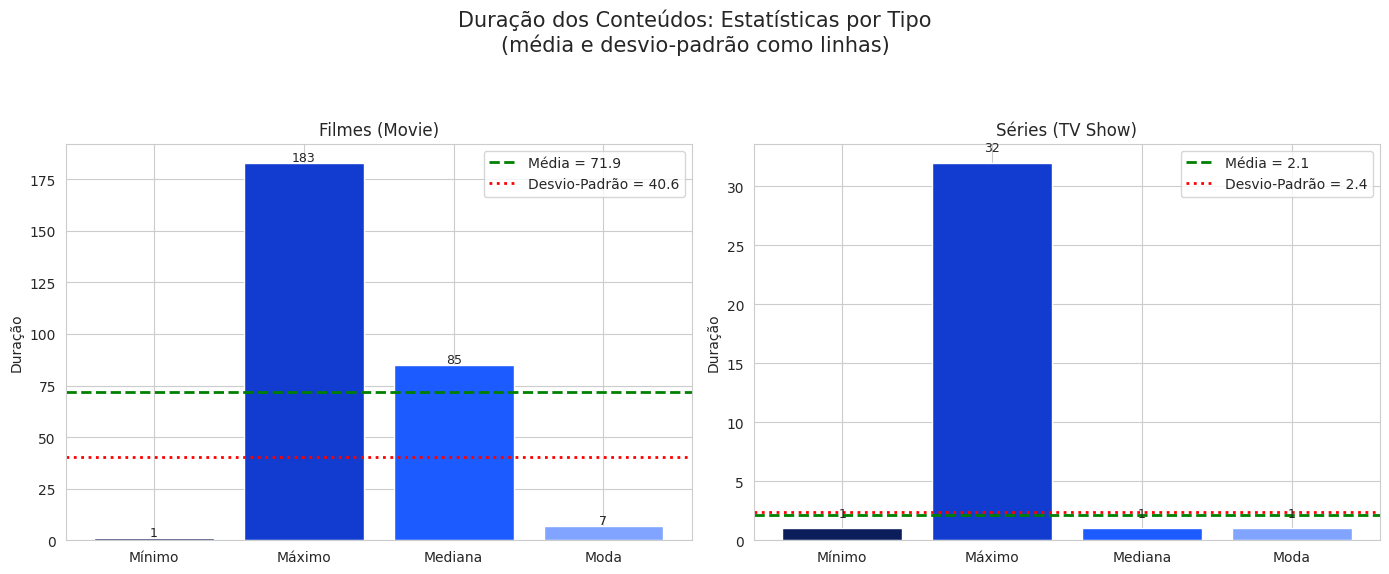

In [152]:
# Cria Gráfico com visão estatística de mínimo, máximo, mediana, média, moda e desvio padrão

# Define função segura para obter a moda
def calcular_moda(serie):
    try:
        return mode(serie.dropna())
    except:
        return np.nan

# Remove registros inválidos
df_filtrado = df_convertido[df_convertido['duracao_qtd'].notnull()]

# Redefine novamente estatísticas com base no novo campo duration_int
estatisticas_duracao = df_filtrado.groupby('tipo')['duracao_qtd'].agg(['min', 'max', 'median', 'std']).reset_index()
estatisticas_duracao['mode'] = df_filtrado.groupby('tipo')['duracao_qtd'].agg(calcular_moda).values

# Renomeia colunas para exibição
estatisticas_duracao.columns = ['Tipo', 'Mínimo', 'Máximo', 'Mediana', 'Desvio-Padrão', 'Moda']
medias = df_filtrado.groupby('tipo')['duracao_qtd'].mean()

# Separa por tipo
estatisticas_filmes = estatisticas_duracao[estatisticas_duracao['Tipo'] == 'Movie'].set_index('Tipo')
estatisticas_series = estatisticas_duracao[estatisticas_duracao['Tipo'] == 'TV Show'].set_index('Tipo')

# Paleta Disney+
cores_barras = {
    'Mínimo': '#0C1D5B',
    'Máximo': '#113CCF',
    'Mediana': '#1C5BFF',
    'Moda': '#80A4FF'
}

# Geração dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Duração dos Conteúdos: Estatísticas por Tipo\n(média e desvio-padrão como linhas)', fontsize=15)

def plotar_estatisticas(ax, dados, tipo, media_valor):
    categorias = ['Mínimo', 'Máximo', 'Mediana', 'Moda']
    valores = [dados[c] for c in categorias]
    cores = [cores_barras[c] for c in categorias]

    barras = ax.bar(categorias, valores, color=cores)

    for bar, valor in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, valor + 1, f'{valor:.0f}', ha='center', fontsize=9)

    ax.axhline(media_valor, color='green', linestyle='--', linewidth=2, label=f'Média = {media_valor:.1f}')
    ax.axhline(dados['Desvio-Padrão'], color='red', linestyle=':', linewidth=2, label=f'Desvio-Padrão = {dados["Desvio-Padrão"]:.1f}')

    ax.set_title(f'{tipo}')
    ax.set_ylabel('Duração')
    ax.legend()

# Gráfico para Filmes
plotar_estatisticas(axs[0], estatisticas_filmes.iloc[0], 'Filmes (Movie)', medias['Movie'])

# Gráfico para Séries
plotar_estatisticas(axs[1], estatisticas_series.iloc[0], 'Séries (TV Show)', medias['TV Show'])

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

**Análise do gráfico Duração dos Conteúdos: Estatísticas dos Filmes (Movie)**

***Mínimo:*** Representa o menor valor de duração de conteúdo do tipo filme.  Com o valor mínimo de 1, pode representar algum conteúdo promocional ou mesmo um curta-metragem.

***Máximo:*** Representa o maior valor em relação à duração de conteúdo do tipo filme.  Com o valor de 183 minutos, pode representar um filme mais antigo (clássico) ou filmes que possuam conteúdo extendido como cenas extras, falhas de gravação, etc.

***Média:*** Representada por uma linha tracejada verde, representa o tempo médio de duração dos filmes da plataforma, no entanto pode ser impactada pela distribuição dos filmes entre curtas e longas metragens.

***Mediana:*** Representa o valor central de duração dos filmes.  A metade inferior tem duração menor e a metade superior tem duração maior.  É um quantitativo mais estável em relação à média pois "desconta" as maiores variações, ou seja, a duração média dos filmes é de 85 minutos.

***Moda:*** É a medida que representa a duração mais frequente na plataforma, ou seja, a maior parte dos filmes disponíveis tem 7 minutos de duração.

***Desvio-Padrão:***  Representa a dispersão dos valores em relação à média. Podemos observar um desvio padrão de 40.6 abaixo da média de 71.9 indicando que há conteúdos com durações bem diversas na plataforma.

***Em resumo: *** Percebemos na base de filmes que ele é composto tanto por curta-metragens quanto por longa metragens, com uma predominância em termos de quantidade dos curta-metragens indicados pela moda de 7 minutos.

**Análise do gráfico Duração dos Conteúdos: Estatísticas das Séries (TV Shows)**

***Mínimo:*** Representa a menor quantidade de temporadas de uma sério. Com o valor mínimo de 1, pode representar uma minissérie ou uma série com apenas uma temporada.

***Máximo:*** Representa o número máximo de temporadas de uma série. Neste caso com o valor de 32 indica que o dataset apresenta séries com grande longevidade e/ou com muitas temporadas lançadas.

***Mediana:*** Representa o valor central de quantidade de temporadas das séries.  A metade inferior tem quantidade menor e a metade superior tem quantidade maior.  É um quantitativo mais estável em relação à média pois "desconta" as maiores variações, neste caso, a mediana é de apenas 1 temporada.

***Moda:*** É a medida que representa a duração mais frequente na plataforma, ou seja, a maior parte das séries possui apenas 1 temporada.

***Média:*** Representada por uma linha tracejada verde, representa a quantidade média de temporadas das séries na plataforma.  Neste caso foi apurada uma média de 2,1 temporadas.

***Desvio-Padrão:***  Representa a dispersão dos valores em relação à média. Podemos observar que o desvio padrão neste caso é de 2,4 e está bem alinhado à média, indicando que não há uma variação muito grande de dispersão.

***Em Resumo:***  Percebemos que a base de séries em relação à duração é composta em sua maioria por conteúdos com apenas 1 temporada conforme demonstrado pela moda e que com um desvio padrão muito próximo da média indica não haver grande dispersão.  O outlier identificado pelo máximo com 32 temporadas não se trata de nenhum erro de preenchimento mas sim de seriado mais longevo.

### 3.2.3.3 Análise Estatística Descritiva em relação à Classificação Etária

Neste bloco avaliamos a frequencia da Classificação Etária do conteúdo disponibilizado.  Verificar se vale incluir também um gráfico com a mudança dessa frequencia em relação ao ano em que o conteúdo foi disponibilizado na plataforma.

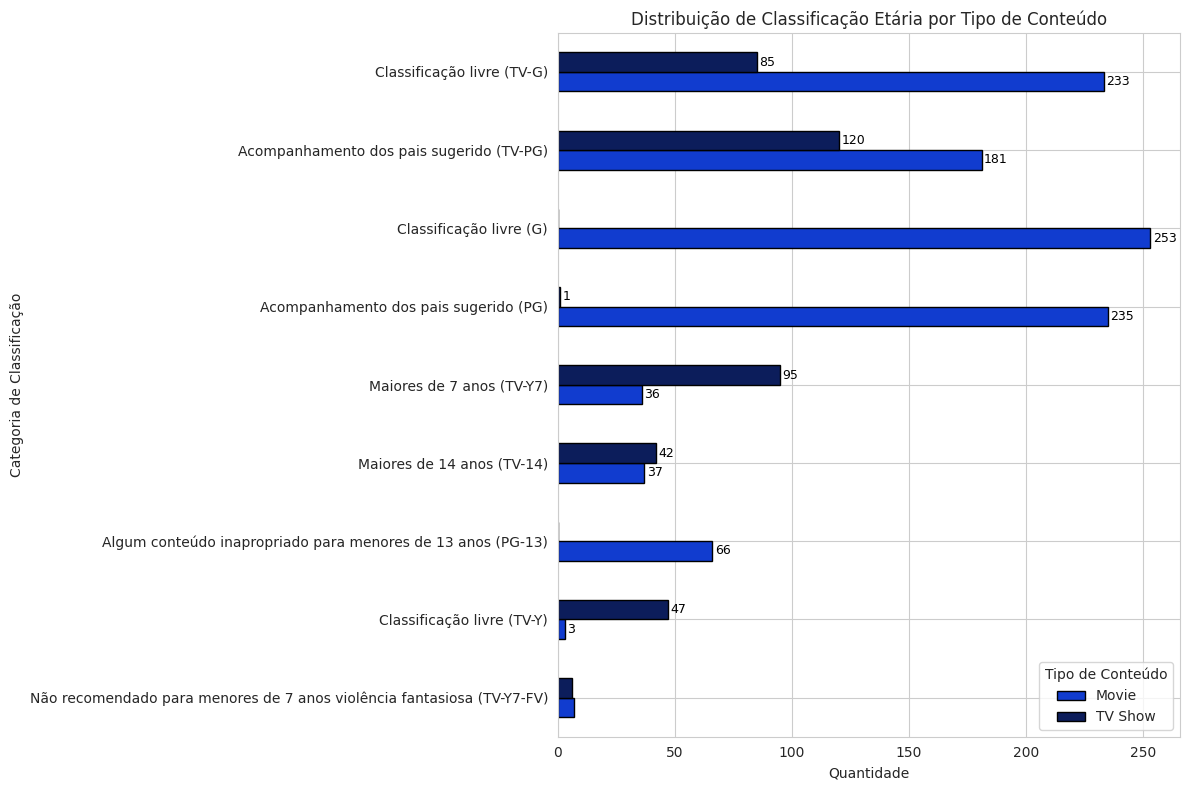

In [153]:
# Gráfico em barras horizontais para Distribuição da Classificação Etária por Tipo de Conteúdo

# Define o agrupamento detalhado único por classificação, evitando repetição de rótulos
agrupamento_detalhado_unico = {
    'G': 'Classificação livre (G)',
    'TV-Y': 'Classificação livre (TV-Y)',
    'TV-G': 'Classificação livre (TV-G)',
    'PG': 'Acompanhamento dos pais sugerido (PG)',
    'TV-PG': 'Acompanhamento dos pais sugerido (TV-PG)',
    'TV-Y7': 'Maiores de 7 anos (TV-Y7)',
    'TV-Y7-FV': 'Não recomendado para menores de 7 anos violência fantasiosa (TV-Y7-FV)',
    'PG-13': 'Algum conteúdo inapropriado para menores de 13 anos (PG-13)',
    'TV-14': 'Maiores de 14 anos (TV-14)',
    'R': 'Menores de 17 anos apenas acompanhados dos pais (R)',
    'NC-17': 'Não recomendado para menores de 17 (NC-17)',
    'TV-MA': 'Não recomendado para menores de 17 (TV-MA)'
}

# Aplica novo mapeamento
df['categoria_detalhada_unica'] = df['classificacao'].map(agrupamento_detalhado_unico)
df_class = df.dropna(subset=['categoria_detalhada_unica'])

# Agrupa por categoria e tipo de conteúdo
df_grouped_unico = df_class.groupby(['categoria_detalhada_unica', 'tipo']).size().unstack(fill_value=0)

# Ordena pela soma total
df_grouped_unico['Total'] = df_grouped_unico.sum(axis=1)
df_grouped_unico = df_grouped_unico.sort_values(by='Total', ascending=True).drop(columns='Total')

# Cores
cor_filmes = '#113CCF'
cor_series = '#0C1D5B'
cor_rotulo = 'white'

# Plot
ax = df_grouped_unico.plot(kind='barh', figsize=(12, 8), color=[cor_filmes, cor_series], edgecolor='black')
plt.title('Distribuição de Classificação Etária por Tipo de Conteúdo')
plt.xlabel('Quantidade')
plt.ylabel('Categoria de Classificação')
plt.legend(title='Tipo de Conteúdo')

# Rótulos
for container in ax.containers:
    for bar in container:
        largura = bar.get_width()
        if largura > 0:
            ax.text(
                bar.get_x() + largura + 1,
                bar.get_y() + bar.get_height() / 2,
                int(largura),
                ha='left',
                va='center',
                fontsize=9,
                color=cor_rotulo if container.datavalues[0] == largura else 'black'
            )

plt.tight_layout()
plt.show()

Glossário das classificações etárias listadas no eixo x para melhor compreensão do significado:

*   G : General Audience (Classificação Livre)
*   PG : Parental Guidance Suggested (Acompanhamento dos pais sugerido)
*   PG-13 : Parents Strongly Cautioned (Algum conteúdo inapropriado para menores de 13)
*   R : Restricted (Menores de 17 apenas acompanhados dos pais)
*   NC-17 : Adults Only (Não recomendado para menores de 17)
*   TV-Y :  All Children (Todos os públicos)
*   TV-Y7 : Directed to Older Children (Maiores de 7 anos)
*   TV-Y7-FV : Older children and containing fantasy violence (Não recomendado para menores de 7 anos violência fantasiosa)
*   TV-G : General Audience (Livre)
*   TV-PG : Parental Guidance Suggested (Acompanhamento dos pais sugerido)
*   TV-14 : Parents Strongly Cautioned (Maiores de 14 anos)
*   TV-MA : Mature Audience Only (Apenas para adultos)

Podemos observar que há três colunas com o rótulo de "Classificação livre" (G, TV-Y e TV-G), que somadas representam 33,7% dos filmes e 9,1% das séries, dando um total de 42,8% do conteúdo disponível na plataforma.  A segunda classificação mais destacada é "Acompanhamento dos pais sugerido" (PG e TV_PG), com 28,6% dos Filmes e 8,34% das Series, representando um total de 37% dos títulos disponíveis.  Importante destacar que não há conteúdo para maiores de 14 anos na plataforma, evidenciando o foco de seu conteúdo na família e em crianças e adolescentes abrangendo todas as faixas etárias com seu conteúdo de classificação livre.

In [154]:
#Criação de campo adicional para agrupamento em relação à classificação
# Dicionário de agrupamento por nova classificação
mapa_classificacao = {
    'G': 'Classificação livre',
    'TV-Y': 'Classificação livre',
    'TV-G': 'Classificação livre',
    'PG': 'Acompanhamento dos pais sugerido',
    'TV-PG': 'Acompanhamento dos pais sugerido',
    'TV-Y7': 'Maiores de 7 anos',
    'TV-Y7-FV': 'Maiores de 7 anos',
    'PG-13': 'Algum conteúdo inapropriado para menores de 13',
    'TV-14': 'Maiores de 14 anos',
    'R': 'Menores de 17 anos apenas acompanhados dos pais',
    'NC-17': 'Não recomendado para menores de 17',
    'TV-MA': 'Não recomendado para menores de 17'
}

# Cria nova coluna com base no dicionário de mapeamento
df_convertido['classificacao_agrupada'] = df_convertido['classificacao'].map(mapa_classificacao)

# Preenche os vazios com 'Classificação desconhecida'
#df['classificacao_agrupada'] = df['classificacao_agrupada'].fillna('Classificação desconhecida')

# Exibe os primeiros resultados para conferência
print(df_convertido[['classificacao', 'classificacao_agrupada']].drop_duplicates().sort_values(by='classificacao'))

   classificacao                          classificacao_agrupada
9              G                             Classificação livre
1             PG                Acompanhamento dos pais sugerido
5          PG-13  Algum conteúdo inapropriado para menores de 13
6          TV-14                              Maiores de 14 anos
0           TV-G                             Classificação livre
3          TV-PG                Acompanhamento dos pais sugerido
69          TV-Y                             Classificação livre
51         TV-Y7                               Maiores de 7 anos
82      TV-Y7-FV                               Maiores de 7 anos
4            NaN                                             NaN


Como parte das avaliações foi criado um campo adicional chamado de '*classificacao_agrupada*', com base nas características em comum conforme a seguir:

*   Classificação livre  (agrupar G, TV-Y e TV-G)
*   Acompanhamento dos pais sugerido (agrupar PG e TV-PG)
*   Maiores de 7 anos (Agrupar TV-Y7 e TV-Y7-FV)
*   Algum conteúdo inapropriado para menores de 13 (Manter apenas PG-13)
*   Maiores de 14 anos (Manter TV-14)
*   Menores de 17 anos apenas acompanhados dos pais (Manter R)
*   Não recomendado para menores de 17 (Agrupar NC-17 e TV-MA)

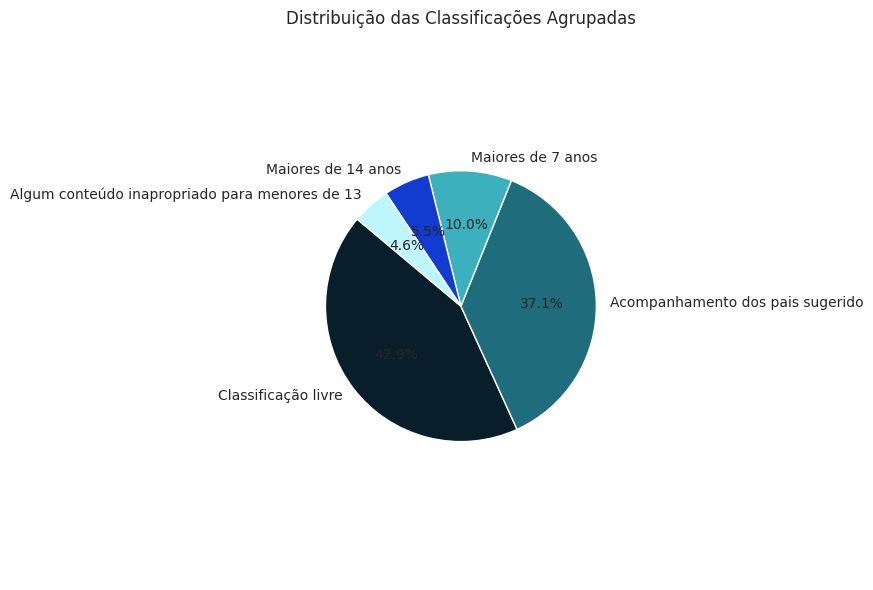

In [155]:
#Cria um gráfico de pizza para mostrar os % de cada classificação agrupada
# Contagem por categoria
contagem_classificacao = df_convertido['classificacao_agrupada'].value_counts()

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(contagem_classificacao, labels=contagem_classificacao.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classificações Agrupadas')
plt.axis('equal')
plt.tight_layout()
plt.show()

Após o agrupamento, podemos confirmar que o rótulo de "Classificação livre" (G, TV-Y e TV-G) representa 42,8% do conteúdo disponível na plataforma. A segunda classificação mais destacada é "Acompanhamento dos pais sugerido" (PG e TV_PG), com 37,1% dos títulos disponíveis.

### 3.2.3.4 Análise Estatística Descritiva em relação ao Tempo entre Lançamento e Adição do Conteúdo no Disney+

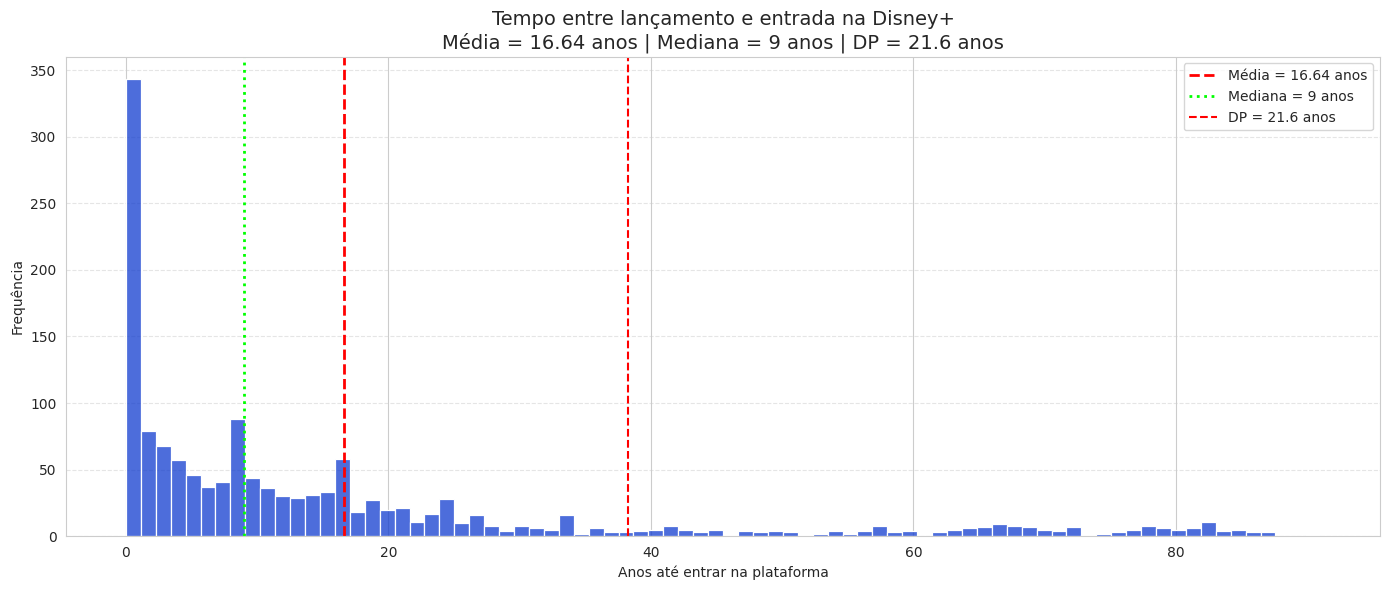

In [156]:
# Gráfico de colunas que mostra o tempo entre o lançamento de um título e sua adição na plataforma Disney+

# Calcula o tempo entre lançamento e entrada na plataforma
df_convertido['anos_ate_entrada'] = df_convertido['ano_adicionado'] - df_convertido['ano_lancamento']

# Remove valores nulos e negativos
df_valid = df_convertido[df_convertido['anos_ate_entrada'].notnull() & (df_convertido['anos_ate_entrada'] >= 0)]

# Calcula estatísticas
media = df_valid['anos_ate_entrada'].mean()
mediana = df_valid['anos_ate_entrada'].median()
dp = df_valid['anos_ate_entrada'].std()

# Cores inspiradas na identidade visual do Disney+
cor_barras = '#113CCF'         # azul Disney+
cor_media = '#FF0000'          # vermelho
cor_mediana = '#00FF00'        # verde

# Cria o histograma
plt.figure(figsize=(14, 6))
sns.histplot(df_valid['anos_ate_entrada'], bins=80, color=cor_barras)

# Linhas de média, mediana e desvio padrão
plt.axvline(media, color=cor_media, linestyle='--', linewidth=2, label=f'Média = {media:.2f} anos')
plt.axvline(mediana, color=cor_mediana, linestyle=':', linewidth=2, label=f'Mediana = {int(mediana)} anos')
plt.axvline(media + dp, color=cor_media, linestyle='--', linewidth=1.5, label=f'DP = {dp:.1f} anos')

# Título e eixos
plt.title('Tempo entre lançamento e entrada na Disney+\nMédia = {:.2f} anos | Mediana = {} anos | DP = {:.1f} anos'
          .format(media, int(mediana), dp), fontsize=14)
plt.xlabel('Anos até entrar na plataforma')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Este gráfico mostra uma média de 16,6 anos entre a data de lançamento e a data de entrada na plataforma.  Este valor é afetado pela grande quantidade de filmes antigos adicionados no momento da inauguração em 2019.  A mediana nos fornece um valor mais aproximado de até 9 anos para o tempo médio entre o lançamento e a entrada na plataforma, como podemos observar no lado esquerdo do gráfico. O desvio padrão de 21.6 anos.

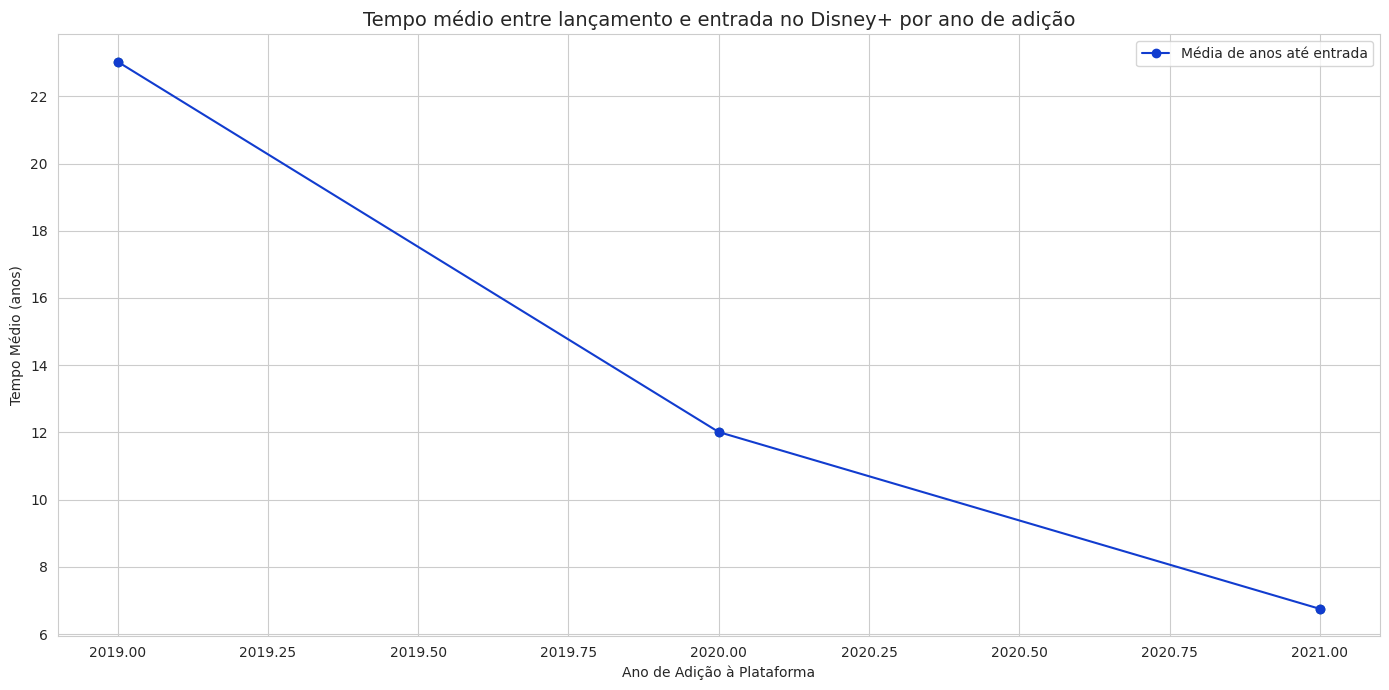

In [157]:
# Gráfico de linhas que mostra o tempo entre o lançamento de um título e sua adição na plataforma Disney+

# Calcula o tempo entre lançamento e entrada na plataforma
df_convertido['anos_ate_entrada'] = df_convertido['ano_adicionado'] - df_convertido['ano_lancamento']

# Remove valores nulos e negativos
df_valid = df_convertido[df_convertido['anos_ate_entrada'].notnull() & (df_convertido['anos_ate_entrada'] >= 0)]

# Agrupa por ano de adição e calcula média de anos até entrada
df_media_por_ano = df_valid.groupby('ano_adicionado')['anos_ate_entrada'].mean().reset_index()

# Define cores editáveis
cor_linha = '#113CCF'
cor_ponto = '#1f6c7d'

# Cria gráfico de linha
plt.figure(figsize=(14, 7))
plt.plot(df_media_por_ano['ano_adicionado'], df_media_por_ano['anos_ate_entrada'], marker='o', color=cor_linha, label='Média de anos até entrada')
plt.scatter(df_media_por_ano['ano_adicionado'], df_media_por_ano['anos_ate_entrada'], color=cor_ponto)

# Título e eixos
plt.title('Tempo médio entre lançamento e entrada no Disney+ por ano de adição', fontsize=14)
plt.xlabel('Ano de Adição à Plataforma')
plt.ylabel('Tempo Médio (anos)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Com este outro gráfico, verificamos que houve um grande volume de títulos adicionados em 2019 em função do lançamento da plataforma de filmes com mais tempo desde e o lançamento (carga inicial) e ao longo dos anos este tempo tem reduzido consideravelmente chegando cada vez mais próximo do lançamento simultâneo entre cinemas e plataforma de streaming.

### 3.2.3.5 Análise Estatística Descritiva em relação às Categorias dos Conteúdos

/tmp/ipython-input-158-531610109.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Blues', num_categorias + 3)


<Figure size 1600x900 with 0 Axes>

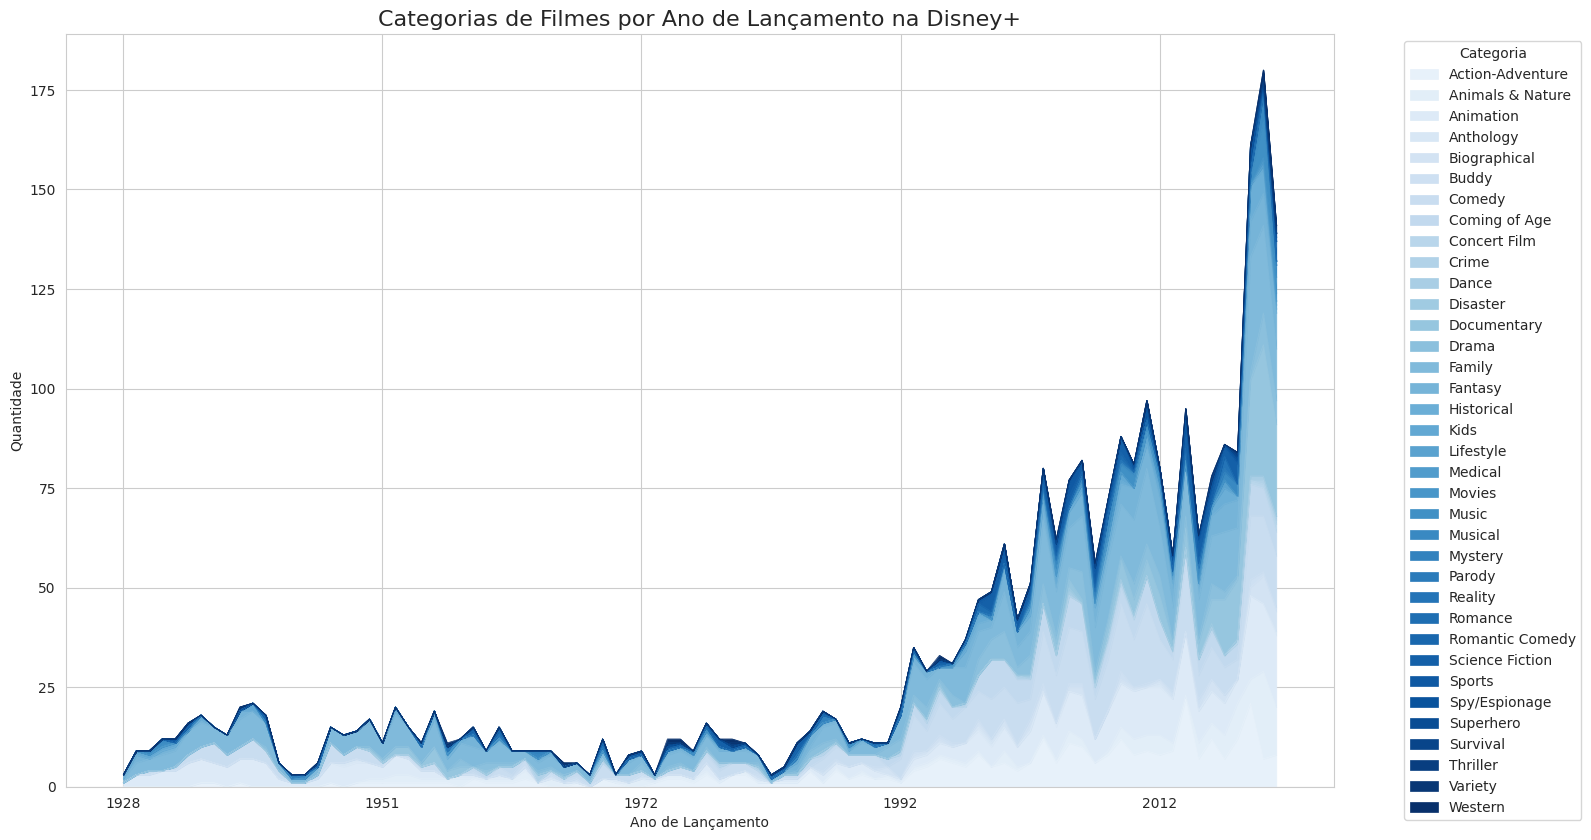

In [158]:
# Gráfico de Área Empilhada para evolução das Categorias ao longo dos Anos de Lançamento
# Filtra apenas os registros de filmes e remove nulos
df_filmes = df[df['tipo'] == 'Movie'].dropna(subset=['generos', 'ano_lancamento'])

# Expande o campo multivalorado 'generos'
df_exploded = df_filmes.copy()
df_exploded['generos'] = df_exploded['generos'].str.split(', ')
df_exploded = df_exploded.explode('generos')
df_exploded['generos'] = df_exploded['generos'].str.strip()

# Agrupa por ano de lançamento e gêneros
df_grouped = df_exploded.groupby(['ano_lancamento', 'generos']).size().reset_index(name='Quantidade')

# Cria pivot para plotagem
df_pivot = df_grouped.pivot(index='ano_lancamento', columns='generos', values='Quantidade').fillna(0)

# Cria paleta de cores Disney+ customizável (degradê de azul)
num_categorias = len(df_pivot.columns)
cmap = get_cmap('Blues', num_categorias + 3)
cores_disney = [to_hex(cmap(i)) for i in range(3, num_categorias + 3)]

# Plotagem
plt.figure(figsize=(16, 9))
ax = df_pivot.plot(kind='area', stacked=True, figsize=(16, 9), color=cores_disney, linewidth=0.5)

# Ajustes visuais
plt.title('Categorias de Filmes por Ano de Lançamento na Disney+', fontsize=16)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [159]:
# Filtra apenas filmes e dados válidos
df_filmes = df_convertido[df_convertido['tipo'] == 'Movie'].dropna(subset=['generos', 'ano_lancamento'])
df_filmes['generos'] = df_filmes['generos'].str.split(', ')
df_filmes_exploded = df_filmes.explode('generos')

# Filtra apenas o ano de 2020
df_filmes_2020 = df_filmes_exploded[df_filmes_exploded['ano_lancamento'] == 2020]

# Agrupa por categoria e conta ocorrências
categorias_2020 = df_filmes_2020['generos'].value_counts().head(5).reset_index()
categorias_2020.columns = ['Categoria', 'Quantidade']
categorias_2020

,Categoria,Quantidade
0,Documentary,33
1,Family,22
2,Animals & Nature,22
3,Animation,17
4,Comedy,14


Neste gráfico percebe-se que no ano de 2020 houve um salto de lançamentos de filmes das categorias Documentário (33 títulos), Animais e Natureza  (22 títulos), Família (22 títulos), Animação  (17 títulos) e Comédia (14 títulos).  Este salto provavelmente se deve ao aumento na produção de conteúdo para que pudesse ser consumido durante a pandemia em que houve um aumento considerável do consumo de streaming no período de isolamento.

/tmp/ipython-input-160-1378801374.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Blues', num_categorias + 3)


<Figure size 1600x900 with 0 Axes>

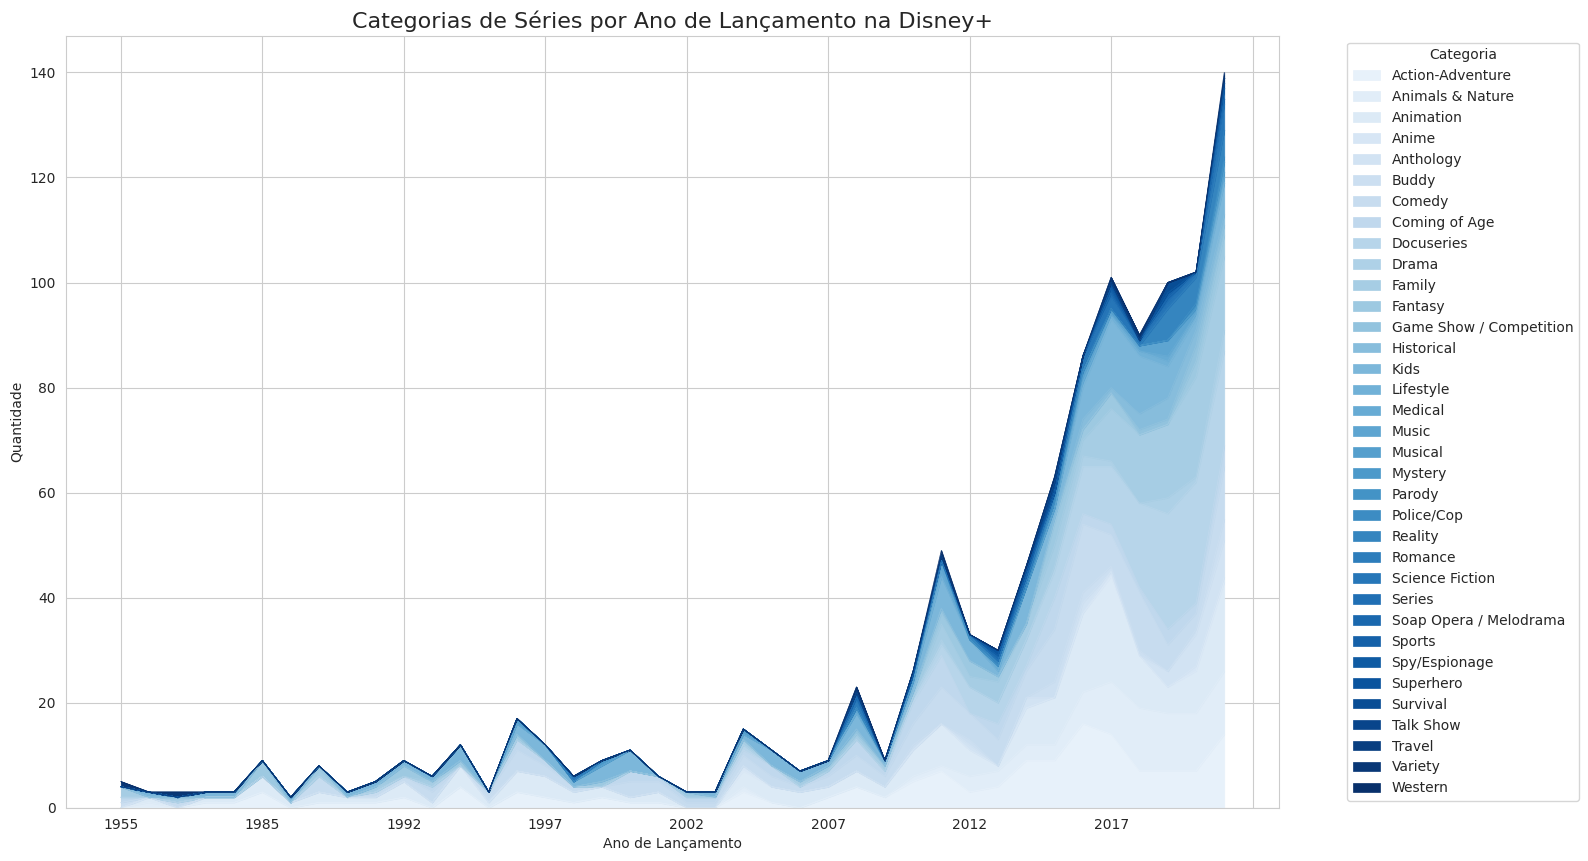

In [160]:
# Gráfico de Área Empilhada para evolução das Categorias ao longo dos Anos de Lançamento
# Filtra apenas os registros de Séries e remove nulos
df_series = df[df['tipo'] == 'TV Show'].dropna(subset=['generos', 'ano_lancamento'])

# Expande o campo multivalorado 'generos'
df_exploded = df_series.copy()
df_exploded['generos'] = df_exploded['generos'].str.split(', ')
df_exploded = df_exploded.explode('generos')
df_exploded['generos'] = df_exploded['generos'].str.strip()

# Agrupa por ano de lançamento e gêneros
df_grouped = df_exploded.groupby(['ano_lancamento', 'generos']).size().reset_index(name='Quantidade')

# Cria pivot para plotagem
df_pivot = df_grouped.pivot(index='ano_lancamento', columns='generos', values='Quantidade').fillna(0)

# Cria paleta de cores Disney+ customizável (degradê de azul)
num_categorias = len(df_pivot.columns)
cmap = get_cmap('Blues', num_categorias + 3)
cores_disney = [to_hex(cmap(i)) for i in range(3, num_categorias + 3)]

# Plotagem
plt.figure(figsize=(16, 9))
ax = df_pivot.plot(kind='area', stacked=True, figsize=(16, 9), color=cores_disney, linewidth=0.5)

# Ajustes visuais
plt.title('Categorias de Séries por Ano de Lançamento na Disney+', fontsize=16)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [161]:
# Filtra apenas séries e dados válidos
df_series = df_convertido[df_convertido['tipo'] == 'TV Show'].dropna(subset=['generos', 'ano_lancamento'])
df_series['generos'] = df_series['generos'].str.split(', ')
df_series_exploded = df_series.explode('generos')

# Filtra apenas o ano de 2020
df_series_2020 = df_series_exploded[df_series_exploded['ano_lancamento'] == 2020]

# Agrupa por categoria e conta ocorrências
categorias_2020 = df_series_2020['generos'].value_counts().head(5).reset_index()
categorias_2020.columns = ['Categoria', 'Quantidade']
categorias_2020

,Categoria,Quantidade
0,Docuseries,23
1,Family,19
2,Animals & Nature,11
3,Animation,8
4,Action-Adventure,7


Neste gráfico percebe-se que no ano de 2020 houve um salto de lançamentos de séries das categorias Documentário (23 títulos), Família  (19 títulos), Animais e Natureza (11 títulos), Animação  (8 títulos) e Ação-Aventura (7 títulos).  Este salto provavelmente se deve ao aumento na produção de conteúdo leve para que pudesse ser consumido durante a pandemia em que houve um aumento considerável do consumo de streaming no período de isolamento.

## 3.2.4 Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### 3.2.4.1 *Duração por Tipo de Conteúdo*



A Duração por Tipo de Conteúdo esclarece como tem sido a curva relacionando tempo de duração para Filmes e também para Séries.

In [162]:
df_convertido.head()

,id_titulo,tipo,titulo,diretor,elenco,pais,data_adicionado,ano_lancamento,classificacao,duracao,generos,descricao,ano_adicionado,duracao_qtd,unidade_duracao,classificacao_agrupada,anos_ate_entrada
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,2021-11-26,2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!,2021,23,min,Classificação livre,5
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,2021-11-26,1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...,2021,91,min,Acompanhamento dos pais sugerido,33
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,2021-11-26,2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.,2021,23,min,Classificação livre,10
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,2021-11-26,2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!",2021,41,min,Acompanhamento dos pais sugerido,0
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,2021-11-25,2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...,2021,1,Season,NaN,0


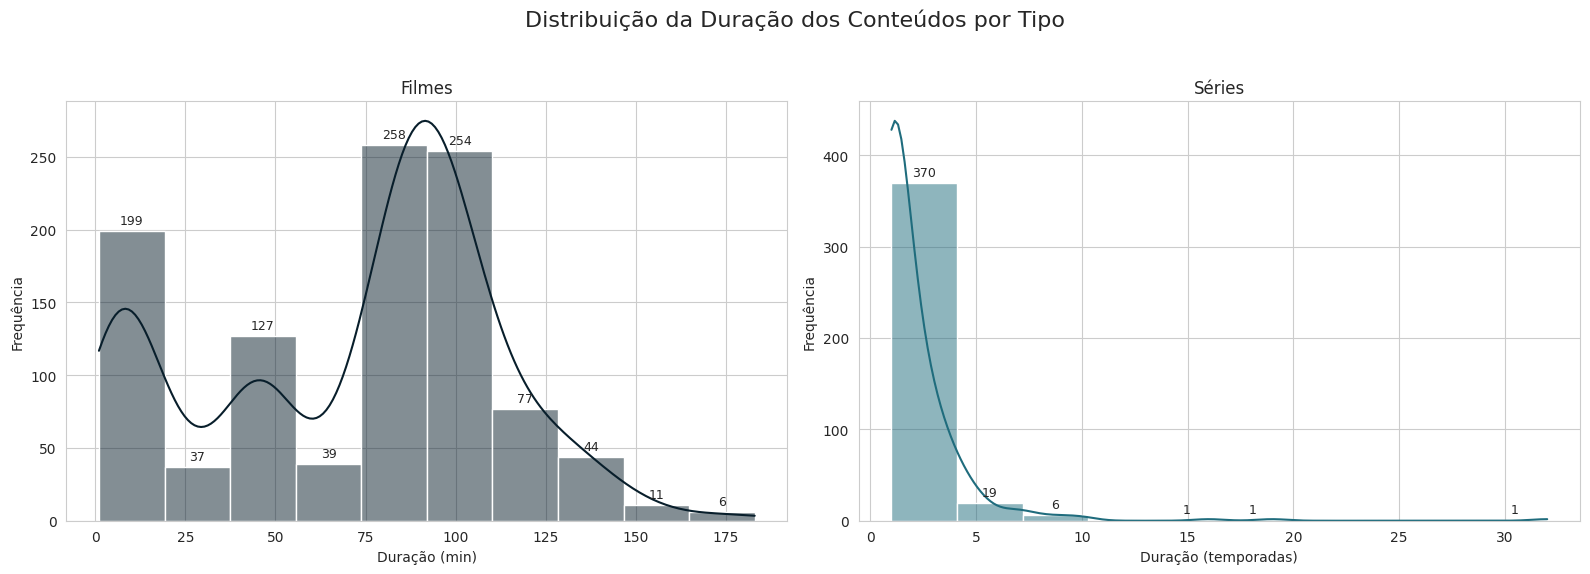

In [163]:
# Histograma da duração dos conteúdos por tipo (um dos atributos)

# Separa por tipo
df_convertido_filmes = df_convertido[df_convertido['tipo'] == 'Movie']
df_convertido_series = df_convertido[df_convertido['tipo'] == 'TV Show']

# Variáveis de personalização
cor_barras_filmes = '#081e2b'
cor_barras_series = '#1f6c7d'
cor_rotulo = 'black'
largura_bin = 10

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribuição da Duração dos Conteúdos por Tipo', fontsize=16)

# Histograma para filmes
hist_filmes = sns.histplot(df_convertido_filmes['duracao_qtd'], bins=largura_bin, kde=True, ax=axs[0], color=cor_barras_filmes)
axs[0].set_title('Filmes')
axs[0].set_xlabel('Duração (min)')
axs[0].set_ylabel('Frequência')

# Adiciona rótulos no gráfico de filmes
for p in hist_filmes.patches:
    height = p.get_height()
    if height > 0:
        axs[0].annotate(f'{int(height)}',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords='offset points',
                        ha='center', fontsize=9)

# Histograma para séries
hist_series = sns.histplot(df_convertido_series['duracao_qtd'], bins=largura_bin, kde=True, ax=axs[1], color=cor_barras_series)
axs[1].set_title('Séries')
axs[1].set_xlabel('Duração (temporadas)')
axs[1].set_ylabel('Frequência')

# Adiciona rótulos no gráfico de séries
for p in hist_series.patches:
    height = p.get_height()
    if height > 0:
        axs[1].annotate(f'{int(height)}',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords='offset points',
                        ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

O histograma mostra a distribuição de duração em relação aos filmes e seriados de forma separada.

***Filmes***

A curva de densidade estimada (KDE) para os filmes apresenta um pico acentuado em torno dos 90 minutos que é a duração média padrão para longa-metragens.
A curva de distribuição cai à direita indicando que embora existam filmes com maior duração, eles são pouco frequentes, ou seja, a plataforma de streaming Disney+ se concentra em filmes com duração padrão.

***Séries***

A curva KDE para as séries revela que a grande maioria de seu conteúdo se concentra com frequencia entre 1 e 3 temporadas, indicando que o foco é em minisséries ou séries mais curtas.
A seguir percebemos algumas séries mais longevas com 4 a 7 temporadas. Esta curva se mantém então praticamente sem variação indicando apenas uma série com 15 até chegar em uma série com mais de 30 temporadas.

### 3.2.4.2 *Ano de Lançamento*

O ano de lançamento representa o ano em que o conteúdo foi disponibilizado para ser acessado seja nos cinemas, exibições particulares, mídias ou em plataformas de streaming.

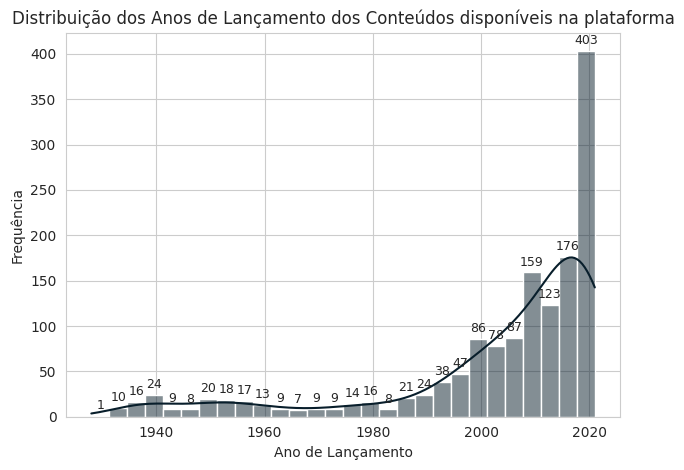

In [164]:
# Histograma do Ano de Lançamento (um dos atributos)

# Cria o histograma com curva de densidade
hist = sns.histplot(df_convertido['ano_lancamento'], kde=True)

# Título e rótulos dos eixos
plt.title('Distribuição dos Anos de Lançamento dos Conteúdos disponíveis na plataforma')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Frequência')

# Adiciona rótulos sobre as barras
for p in hist.patches:
    altura = p.get_height()
    if altura > 0:
        plt.annotate(f'{int(altura)}',
                     xy=(p.get_x() + p.get_width() / 2, altura),
                     xytext=(0, 5),
                     textcoords='offset points',
                     ha='center',
                     fontsize=9)

plt.tight_layout()
plt.show()

Observamos que a curva KDE é ascendente mostrando que a maior parte do conteúdo disponibilizado na plataforma de streaming Disney+ é mais recente, tendo esta curva se intensificado a partir dos anos 2000.

### 3.2.4.3 Ano de Inclusão na plataforma Disney+

O Ano de Inclusão na plataforma representa o ano em que o conteúdo foi incluído na base do streaming Disney+.

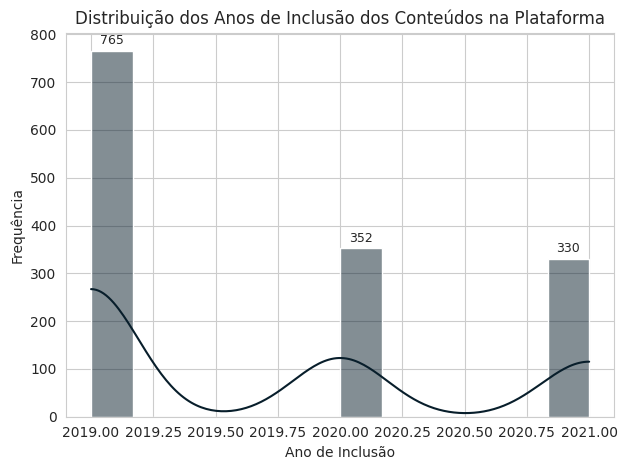

In [165]:
# Histograma do Ano de Inclusão na Plataforma (um dos atributos)

# Cria o histograma com curva de densidade
hist = sns.histplot(df_convertido['ano_adicionado'], kde=True)

# Título e rótulos dos eixos
plt.title('Distribuição dos Anos de Inclusão dos Conteúdos na Plataforma')
plt.xlabel('Ano de Inclusão')
plt.ylabel('Frequência')

# Adiciona rótulos sobre as barras
for p in hist.patches:
    altura = p.get_height()
    if altura > 0:
        plt.annotate(f'{int(altura)}',
                     xy=(p.get_x() + p.get_width() / 2, altura),
                     xytext=(0, 5),
                     textcoords='offset points',
                     ha='center',
                     fontsize=9)

plt.tight_layout()
plt.show()

A plataforma Disney+ foi lançada em novembro de 2019 nos Estados Unidos, Canadá e Países Baixos, expandindo-se para outros países europeus e Índia pouco tempo depois, já na América Latina o serviço foi lançado em novembro de 2020.  Dessa forma, percebemos que houve um grande conteúdo adicionado no lançamento e depois a curva se mostra mantida até 2021.

### 3.2.4.4 Gêneros ou Categorias de Conteúdo

Os gêneros ou categorias de conteúdo representam o estilo do conteúdo disponibilizado.

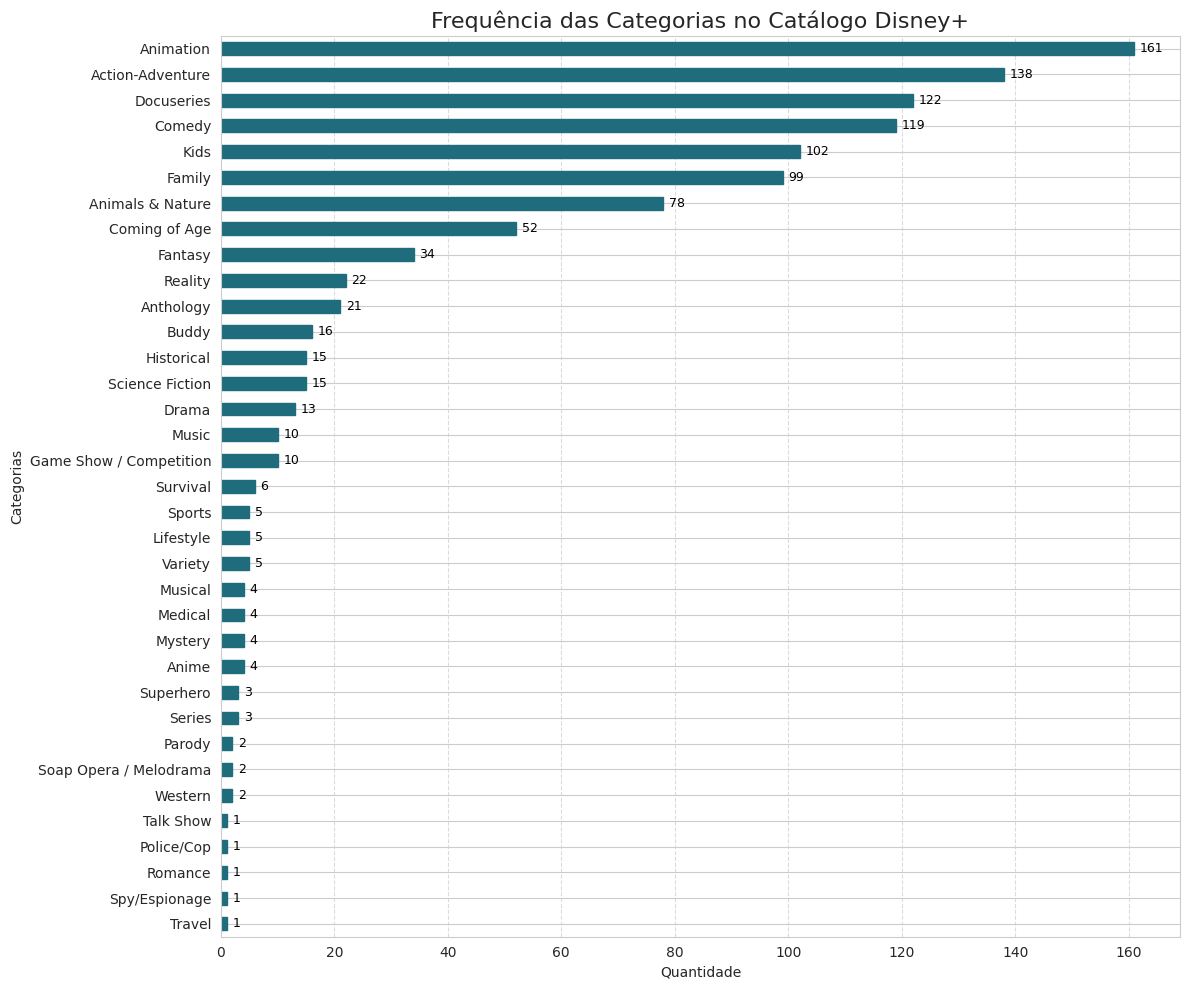

In [166]:
# Gráfico de barras horizontais dos Gêneros ou Categorias de Conteúdo

# Conta a frequência das categorias de forma ordenada
frequencia_categorias = df_exploded['generos'].value_counts()

# Define cores Disney+ e rótulo
cor_barras = '#1f6c7d'
cor_rotulo = 'black'

# Cria gráfico de barras horizontais
plt.figure(figsize=(12, 10))
ax = frequencia_categorias.plot(kind='barh', color=cor_barras, edgecolor='#1f6c7d')

# Inverte o eixo para ter a maior categoria no topo
ax.invert_yaxis()

# Rótulos de valor
for i, v in enumerate(frequencia_categorias):
    ax.text(v + 1, i, str(v), color=cor_rotulo, va='center', fontsize=9)

# Títulos e eixos
plt.title('Frequência das Categorias no Catálogo Disney+', fontsize=16)
plt.xlabel('Quantidade')
plt.ylabel('Categorias')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 3.2.5 Boxplot

Para entender as diferenças entre os tipos de conteúdo, podemos observar como se comportam separadamente. Isso nos permite comparar a média, mediana e desvio padrão de cada tipo, seja Filme ou Série, além de visualizar suas distribuições por meio de boxplots.


In [168]:
# Estatísticas descritivas agrupadas por tipo de conteúdo
df_convertido.groupby('tipo').describe()

data_adicionado                                                      \
                  count                           mean                  min   
tipo                                                                          
Movie              1052  2020-04-20 03:30:47.908745472  2019-10-01 00:00:00   
TV Show             395  2020-08-15 03:02:16.708860928  2019-10-01 00:00:00   

                                                                        \
                         25%                  50%                  75%   
tipo                                                                     
Movie    2019-11-12 00:00:00  2019-11-12 00:00:00  2020-08-15 18:00:00   
TV Show  2019-11-12 00:00:00  2020-06-26 00:00:00  2021-05-03 12:00:00   

                                  ano_lancamento               ...  \
                         max  std          count         mean  ...   
tipo                                                           ...   
Movie    2021-11-26 00:00:00  NaN         1052.0  1999.230989  ...   
TV Show  2021-11-25 00:00:00  NaN          398.0  2013.296482  ...   

        duracao_qtd            anos_ate_entrada                             \
                max        std            count       mean  min  25%   50%   
tipo                                                                         
Movie         183.0  40.595585           1052.0  20.352662  0.0  3.0  12.0   
TV Show        32.0   2.411898            395.0   6.706329 -1.0  1.0   3.0   

                                
          75%   max        std  
tipo                            
Movie    25.0  91.0  23.616468  
TV Show   8.0  64.0   9.449563  

[2 rows x 40 columns]

### 3.2.5.1 *Ano de Inclusão na Plataforma* por Tipo


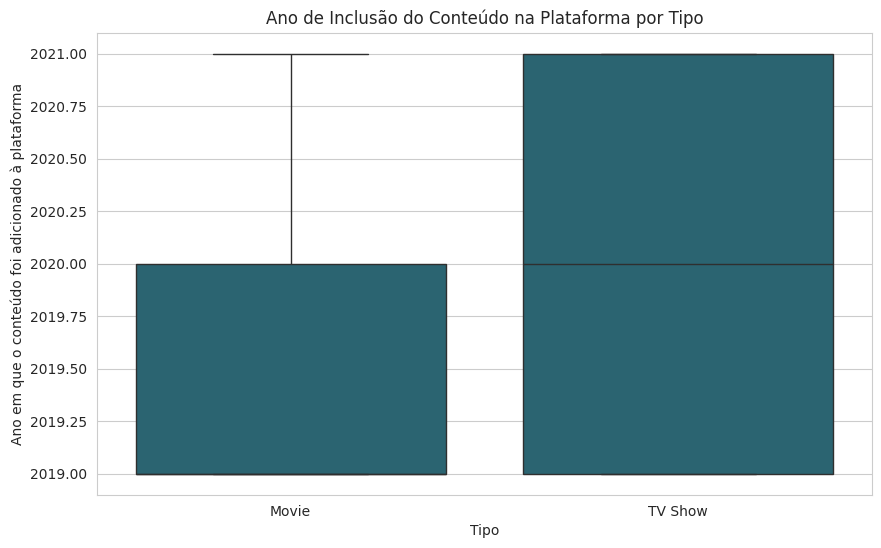

In [169]:
# Boxplot do ano de inclusão do conteúdo por tipo
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo', y='ano_adicionado', data=df_convertido, color='#1f6c7d')
plt.title('Ano de Inclusão do Conteúdo na Plataforma por Tipo')
plt.xlabel('Tipo')
plt.ylabel('Ano em que o conteúdo foi adicionado à plataforma')
plt.show()

Não foram identificados outliers em relação aos Filmes (Movie) fora da mediana.  Já o boxplot das Séries (TV Show) é mais esticado com adições ao catálogo ocorridas mais recentemente mantendo a plataforma sempre com novos conteúdos sendo adicionados.

O gráfico mostra que a Disney+ fez uma inclusão massiva de filmes no início da operação em 2019 apostando principalmente em conteúdo mais antigo e nostálgico, enquanto as séries têm sido adicionadas de maneira mais contínua, alinhadas com uma estratégia de renovação frequente de conteúdo para retenção de público.

### 3.2.5.2 Ano de Lançamento por Tipo

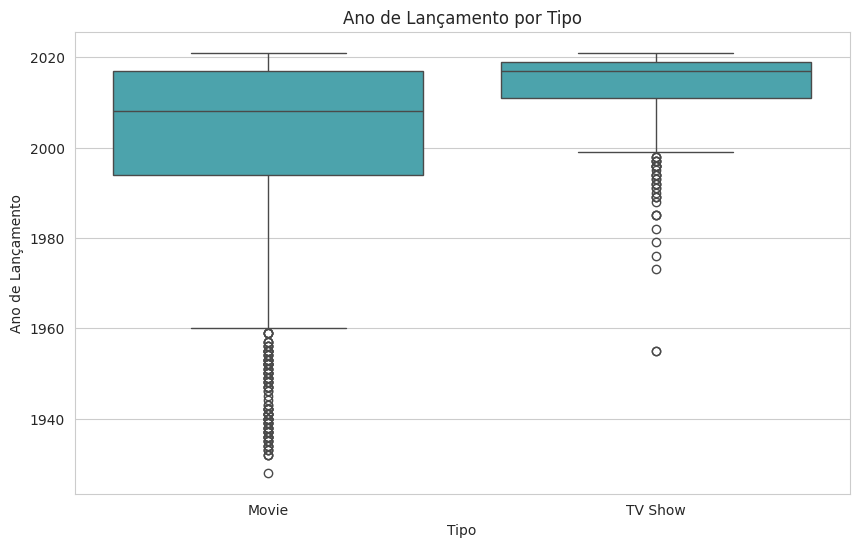

In [170]:
# Boxplot de ano de lancamento por tipo
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo', y='ano_lancamento', data=df_convertido, color='#3cb0bc')
plt.title('Ano de Lançamento por Tipo')
plt.xlabel('Tipo')
plt.ylabel('Ano de Lançamento')
plt.show()

***Filmes***

O boxplot dos Filmes é mais esticado, indicando uma maior variação nos anos de lançamento. Nota-se filmes que foram lançados antes dos anos 1980 (outliers antigos).  Este catálogo se mostra mais abrangente historicamente, oferencendo desde clássicos antigos até conteúdos mais atuais.

***Séries***

A mediana das Séries está mais próxima de anos recentes.  O boxplot mais estreito, mostra a tendência recente de investir mais em novos conteúdos no formato de séries, dessa forma mostra também que os poucos outliers identificados podem ser oriundos de aquisições de conteúdos de outras produtoras.

### 3.2.5.3 *Tempo entre Lançamento e Inclusão na plataforma* por Tipo

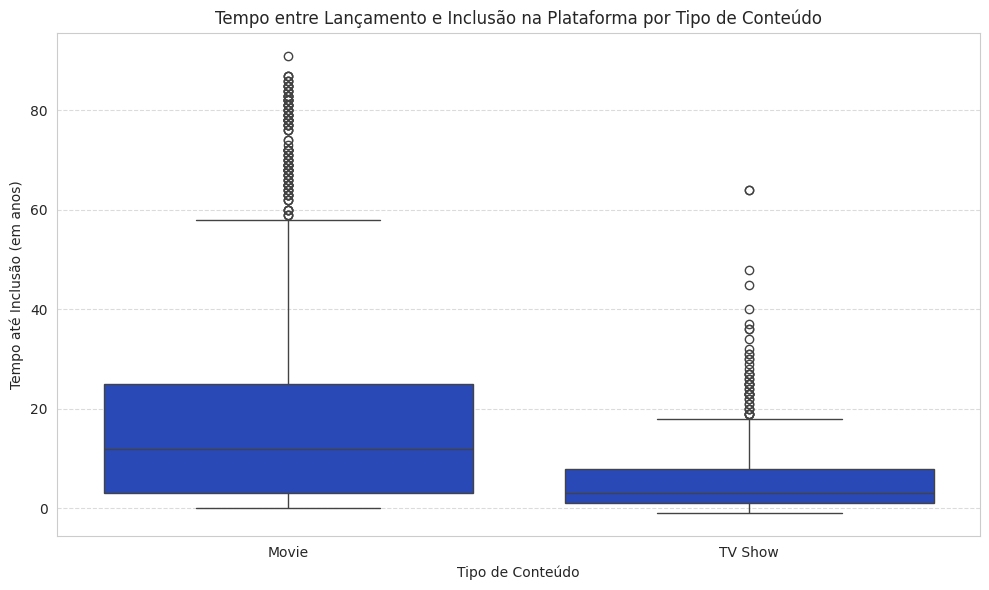

In [171]:
# Boxplot do Tempo entre Lançamento e Inclusão na plataforma por Tipo
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo', y='anos_ate_entrada', data=df_convertido, color='#113CCF')
plt.title('Tempo entre Lançamento e Inclusão na Plataforma por Tipo de Conteúdo')
plt.xlabel('Tipo de Conteúdo')
plt.ylabel('Tempo até Inclusão (em anos)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

***Filmes***

Neste boxplot nota-se que a mediana para filmes é bem maior do que para séries, indicando que os filmes levam cerca de 9 anos ou mais para serem incluídos na plataforma.  Os outliers extremos com diferenças às vezes superiores a 40 anos, indicam que a Disney por possuir um acervo histórico importante de filmes, continua tendo títulos antigos que podem ainda ser incorporados à plataforma.

***Séries***

A estratégia parece ser diferente para as séries onde o boxplot mais enxuto mostra o curto espaço de tempo entre lançamento e inclusão na plataforma.  A distribuição é mais concentrada sugerindo que há produção de conteúdo para ser lançado já diretamente na plataforma.


## 3.2.6 Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [172]:
# Matriz de correlação
print("\nMatriz de Correlação:")
# Select only numerical columns before calculating correlation
numerical_df_convertido = df_convertido.select_dtypes(include=['number'])
print(numerical_df_convertido.corr())


Matriz de Correlação:
                  ano_lancamento  ano_adicionado  duracao_qtd  \
ano_lancamento          1.000000        0.353043    -0.049674   
ano_adicionado          0.353043        1.000000    -0.183949   
duracao_qtd            -0.049674       -0.183949     1.000000   
anos_ate_entrada       -0.999374       -0.319733     0.042431   

                  anos_ate_entrada  
ano_lancamento           -0.999374  
ano_adicionado           -0.319733  
duracao_qtd               0.042431  
anos_ate_entrada          1.000000  


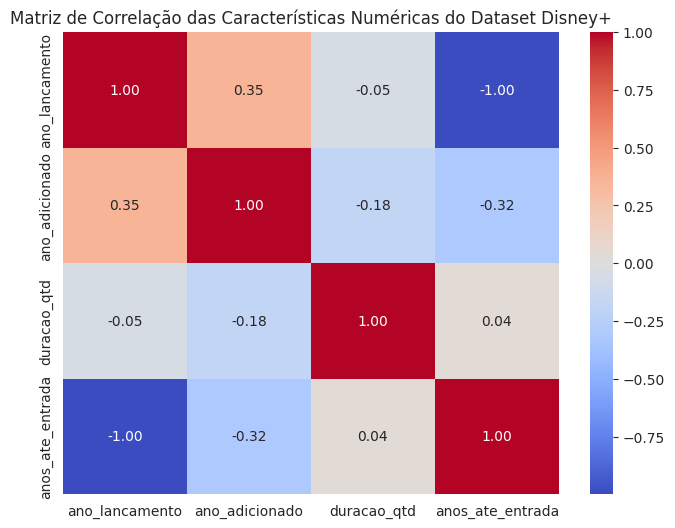

In [173]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
# Use the numerical_df_convertido DataFrame which contains only numerical columns
sns.heatmap(numerical_df_convertido.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset Disney+')
plt.show()

O mapa de calor sugere que há uma correlação forte de 0.35 entre *ano_lançamento* e *ano_adicionado*, indicando que conteúdos mais recentes são adicionados mais rapidamente na plataforma.

Percebe-se também uma correlação negativa de -1.00 entre *anos_ate_entrada* e *ano_lancamento* reforçando que quanto mais novo o conteúdo, mais cedo ele entra na plataforma.  Estas duas correlações podem indicar uma estratégia da Disney+ em incorporar rapidamente conteúdos novos.

Não é possível avaliar com precisão a correlação em relação ao campo *duracao_qtd* uma vez que a ordem de grandeza em minutos ou quantidade de temporadas pode atrapalhar a analise, sendo necessário destacar este campo para ser analisado separadamente em relação às demais variáveis conforme o tipo de conteúdo.

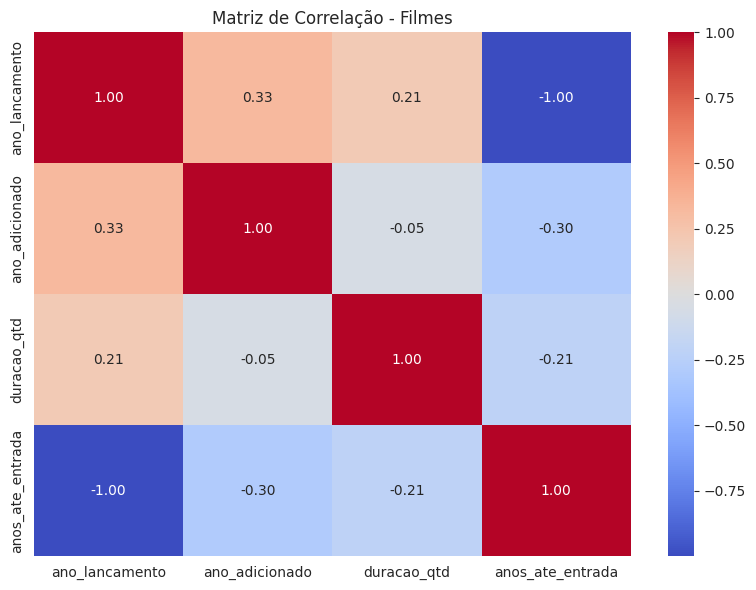

In [174]:
#Cria matriz de correlação e gráfico de calor separadamente para Filmes

df_filmes = df_convertido[df_convertido['tipo'] == 'Movie']

# Seleciona apenas colunas numéricas para cada tipo
numerical_filmes = df_filmes.select_dtypes(include=['number']).dropna()

# Cria gráfico de calor para filmes
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_filmes.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Filmes')
plt.tight_layout()
plt.show()

Analisando este mapa agora com a duracao_qtd ajustada para filmes e sendo medida em minutos, podemos observar que a correlação entre *ano_lancamento* e *ano_adicionado* continua sendo alta (0.33), ou seja, quanto mais recente o lançamento mais recente a entrada na plataforma.

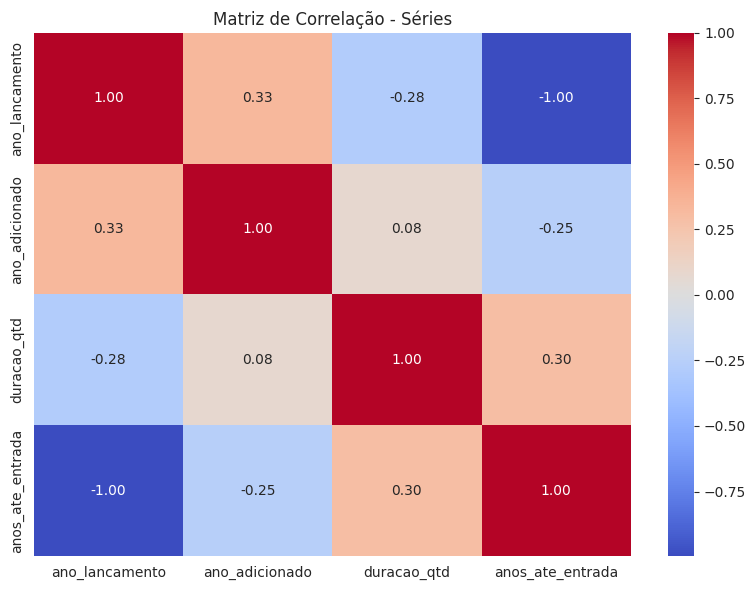

In [175]:
#Cria matriz de correlação e gráfico de calor separadamente para Séries

df_series = df_convertido[df_convertido['tipo'] == 'TV Show']

# Seleciona apenas colunas numéricas para cada tipo
numerical_series = df_series.select_dtypes(include=['number']).dropna()

# Cria gráfico de calor para séries
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_series.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Séries')
plt.tight_layout()
plt.show()

As séries tendem a ser mais recentes e incluídas rapidamente, o que reforça a correlação inversa entre ano de lançamento e tempo até inclusão.  Vide correlação alta entre *ano_adicionado* e *ano_lancamento* (0.33).

# 4. Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## 4.1 Divisão Treino e Teste

In [176]:
# Separar features (X) e target (y)
#X = df_convertido.drop('tipo', axis=1)
#y = df_convertido['tipo']

In [177]:
# Separar os campos numéricos
X = df_convertido[['ano_lancamento', 'ano_adicionado', 'duracao_qtd', 'anos_ate_entrada']].dropna()

In [178]:
# Dividir os dados em conjuntos de treino e teste (sem target)
X_train_raw, X_test_raw = train_test_split(X, test_size=0.2, random_state=42)

In [179]:
print(f"Dimensões de X_train: {X_train_raw.shape}")
print(f"Dimensões de X_test: {X_test_raw.shape}")

Dimensões de X_train: (1157, 4)
Dimensões de X_test: (290, 4)


## 4.2 Padronizacao, Tratamento com K-Means e PCA

Para casos de análise exploratória com futura evolução para modelo não supervisionado, a divisão de dados entre treino e teste é opcional para validação de estabilidade dos padrões.  Desta forma, optamos por utilizar o K-mens como forma de exemplificar esta etapa.



In [180]:
# Inicializar o StandardScaler
scaler = StandardScaler()

In [182]:
# Aprende média e desvio padrão de X_train_std
X_train_std = scaler.fit_transform(X_train_raw)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_std = scaler.transform(X_test_raw)

Padronização separada.  Fit_transform aplicado somente ao treino e Transform aplicado somente ao teste usando os parâmetros aprendidos no treino.

In [183]:
# Exibir as primeiras linhas dos dados padronizados como dataframe
df_std = pd.DataFrame(X_train_std, columns=X_train_raw.columns)
print("\nPrimeiras 5 linhas dos dados padronizados (treino): ")
print(df_std.head())


Primeiras 5 linhas dos dados padronizados (treino): 
   ano_lancamento  ano_adicionado  duracao_qtd  anos_ate_entrada
0        0.764899        0.359236    -0.428415         -0.761255
1       -1.433829       -0.866829     0.756331          1.419677
2        0.764899        0.359236    -1.117722         -0.761255
3       -0.105431       -0.866829     0.864035          0.073996
4        0.444251       -0.866829    -0.148384         -0.482838


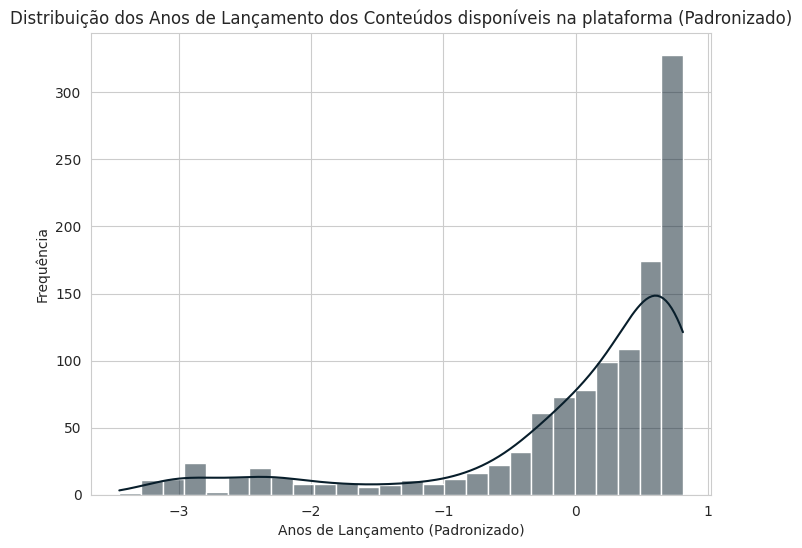

In [184]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_std['ano_lancamento'], kde=True)
plt.title('Distribuição dos Anos de Lançamento dos Conteúdos disponíveis na plataforma (Padronizado)')
plt.xlabel('Anos de Lançamento (Padronizado)')
plt.ylabel('Frequência')
plt.show()

O histograma de *ano_lancamento* após a padronização mostra que os valores foram escalados para o intervalo de -3 a 1, mantendo a forma da distribuição original.

In [185]:
# Aplica K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train_std)

KMeans(n_clusters=3, random_state=42)

In [186]:
# Recupera os nomes das features usadas no treinamento
feature_names = X_train_raw.columns.tolist()

# Cria um DataFrame legível com os centróides
centroides_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)

# Exibe os centróides (em escala padronizada)
print("Centróides (com dados normalizados):")
display(centroides_df)

Centróides (com dados normalizados):


,ano_lancamento,ano_adicionado,duracao_qtd,anos_ate_entrada
0,0.177612,-0.655581,0.403163,-0.204734
1,-2.351888,-0.601039,-0.165557,2.359739
2,0.547805,1.123348,-0.509474,-0.512417


K-Means é um algoritmo de aprendizado não supervisionado usado para agrupamento de dados (clustering) que tem como finalidade agrupar observações semelhantes em um número definido de grupos (clusters), sem usar rótulos previamente definidos.

Neste cenário utilizamos 3 clusters e efetuamos o treinamento do modelo de forma que seja reprodutível.

In [187]:
# Predição
train_labels = kmeans.predict(X_train_std)
test_labels = kmeans.predict(X_test_std)

In [188]:
#Visualizar resultado da Predição
# Para treino
df_train_clusters = X_train_raw.copy()
df_train_clusters['Cluster'] = train_labels

# Para teste
df_test_clusters = X_test_raw.copy()
df_test_clusters['Cluster'] = test_labels

print('Para Treino: \n',df_train_clusters.head())
print('\nPara Teste: \n',df_test_clusters.head())

# Perfil médio por cluster (exemplo para treino)
df_train_clusters.groupby('Cluster').mean()

Para Treino: 
       ano_lancamento  ano_adicionado  duracao_qtd  anos_ate_entrada  Cluster
478             2020            2020           33                 0        2
1432            1972            2019           88                47        1
380             2020            2020            1                 0        2
1091            2001            2019           93                18        0
1127            2013            2019           46                 6        0

Para Teste: 
       ano_lancamento  ano_adicionado  duracao_qtd  anos_ate_entrada  Cluster
1023            1937            2019            9                82        1
381             2019            2020            1                 1        2
843             2017            2019           64                 2        0
427             2020            2020            1                 0        2
192             2018            2021            2                 3        2


,ano_lancamento,ano_adicionado,duracao_qtd,anos_ate_entrada
Cluster,,,,
0,2007.179054,2019.172297,71.604730,11.993243
1,1951.958042,2019.216783,45.202797,67.258741
2,2015.260664,2020.623223,29.236967,5.362559


In [189]:
# Avaliação com silhouette score
silhouette_train = silhouette_score(X_train_std, train_labels)
silhouette_test = silhouette_score(X_test_std, test_labels)

print(f"Silhouette Score (Treino): {silhouette_train:.2f}")
print(f"Silhouette Score (Teste): {silhouette_test:.2f}")

Silhouette Score (Treino): 0.42
Silhouette Score (Teste): 0.39


O Silhouette Score é uma métrica de avaliação da qualidade dos clusters formados por algoritmos como o K-Means.  Ele mede se um ponto está bem agrupado com seus próprios clusters e o quão distante está dos demais pontos de outros clusters.  Neste caso verificamos que estão bem similares - Treino (0.42) e Teste(0.39).

In [190]:
# Redução de dimensionalidade com PCA para visualização
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

O PCA (Principal Component Analysis) é uma técnica estatística utilizada para reduzir a quantidade de dimensões de um dataset, mantendo o máximo de variabilidade de informação possível.  Esta técnica é geralmente aplicada em conjunto com o K-Means porque ajuda a projetar em duas dimensões, o que facilita muito para utilizar scatterplots.

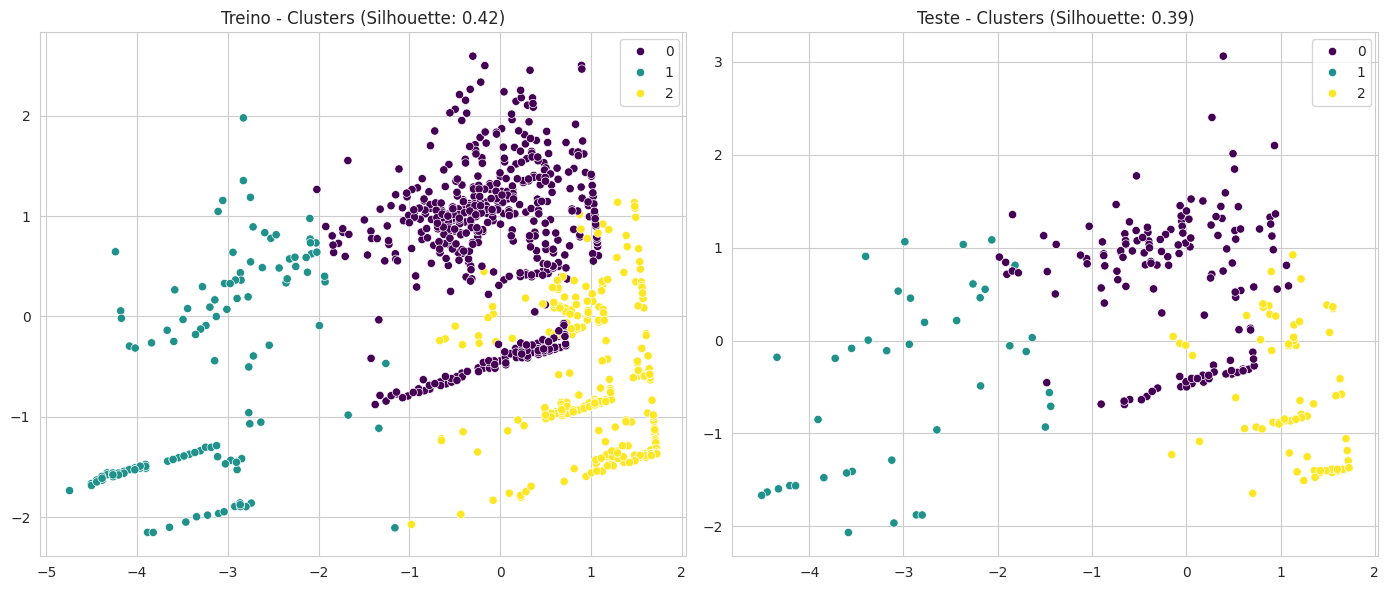

In [191]:
# Visualização dos clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=train_labels, palette='viridis', ax=axes[0])
axes[0].set_title(f'Treino - Clusters (Silhouette: {silhouette_train:.2f})')

sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=test_labels, palette='viridis', ax=axes[1])
axes[1].set_title(f'Teste - Clusters (Silhouette: {silhouette_test:.2f})')

plt.tight_layout()
plt.show()

Observando este scatterplot que mostra a diferenciação entre treino e teste, percebe-se que mesmo em menor volume, o conjunto de teste seguiu basicamente a mesma distribuição que o conjunto de treino.

Este tipo de análise futuramente pode ajudar a separar grupos de conteúdos por características comuns e criar segmentações automáticas sem precisar de rótulos manuais.

In [192]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Disney+:")
df.isnull().sum()

Valores nulos no dataset Disney+:


,0
id_titulo,0
tipo,0
titulo,0
diretor,473
elenco,190
pais,219
data_adicionado,3
ano_lancamento,0
classificacao,3
duracao,0


## 4.3 Outras Transformações e Etapas de Pré-Processamento



### 4.3.1 Tratamento de Valores Nulos

Foram retirados os valores nulos do dataframe *df_convertido* conforme exibido abaixo.

In [193]:
print("Antes:", df.shape)
df_convertido.dropna(inplace=True)
print("Depois:", df_convertido.shape)
df_convertido.isnull().sum()

Antes: (1450, 13)
Depois: (818, 17)


,0
id_titulo,0
tipo,0
titulo,0
diretor,0
elenco,0
pais,0
data_adicionado,0
ano_lancamento,0
classificacao,0
duracao,0


### 4.3.2 Conversão de Formatos e Valores Calculados

Ao longo da análise exploratória foram feitas as conversões dos tipos de dados necessárias para as análises conforme a seguir:

*   data_adicionado (object) --> data_adicionado (datetime)
*   ano_lancamento (object) --> ano_lancamento (integer)
*   duracao (object) --> duracao_qtd (integer) e unidade_duracao (texto)

Também para a etapa de análise foram realizados os cálculos e transformações
*   ano_adicionado (integer) = extraído apenas o ano do campo data_adicionado (datetime)
*   anos_ate_entrada = ano_lancamento - ano_adicionado

Adicionalmente, foi criado um campo de agrupamento '*classificacao_agrupada*'para permitir associações mais rápidas entre as classificações etárias disponíveis no campo '*classificacao*' conforme dicionário a seguir:

    'G': 'Classificação livre',
    'TV-Y': 'Classificação livre',
    'TV-G': 'Classificação livre',
    'PG': 'Acompanhamento dos pais sugerido',
    'TV-PG': 'Acompanhamento dos pais sugerido',
    'TV-Y7': 'Maiores de 7 anos',
    'TV-Y7-FV': 'Maiores de 7 anos',
    'PG-13': 'Algum conteúdo inapropriado para menores de 13',
    'TV-14': 'Maiores de 14 anos',
    'R': 'Menores de 17 anos apenas acompanhados dos pais',
    'NC-17': 'Não recomendado para menores de 17',
    'TV-MA': 'Não recomendado para menores de 17'

### 4.3.4 One-hot-encoding para campo '*generos*' *(listed_in)*

Este campo é multivalorado e pode ser particionado a fim de preparar a base para o futuro modelo.

In [194]:
# Criar cópia do dataset convertido para novo dataset modelagem
df_modelagem = df_convertido.copy()

# Converte para lista
df_modelagem['generos'] = df_modelagem['generos'].apply(
    lambda x: x.split(', ') if pd.notna(x) else []
)

#Cria colunas binárias para cada categoria
mlb = MultiLabelBinarizer()
categorias_encoded = mlb.fit_transform(df_modelagem['generos'])

# Cria dataframe com os nomes das categorias
df_categorias = pd.DataFrame(categorias_encoded, columns=mlb.classes_, index=df_modelagem.index)

# Junta ao dataset original
df_modelagem = pd.concat([df_modelagem.drop(columns=['generos']), df_categorias], axis=1)

# Visualização
print(df_modelagem.head())

   id_titulo   tipo                                 titulo           diretor  \
2         s3  Movie           Ice Age: A Mammoth Christmas      Karen Disher   
5         s6  Movie                      Becoming Cousteau        Liz Garbus   
9        s10  Movie  A Muppets Christmas: Letters To Santa  Kirk R. Thatcher   
12       s13  Movie                        The Pixar Story     Leslie Iwerks   
19       s20  Movie                              Enchanted        Kevin Lima   

                                               elenco           pais  \
2   Raymond Albert Romano, John Leguizamo, Denis L...  United States   
5               Jacques Yves Cousteau, Vincent Cassel  United States   
9   Steve Whitmire, Dave Goelz, Bill Barretta, Eri...  United States   
12  Stacy Keach, John Lasseter, Brad Bird, John Mu...  United States   
19  Amy Adams, Patrick Dempsey, James Marsden, Tim...  United States   

   data_adicionado  ano_lancamento classificacao  duracao  ... Romance  \
2       2021

# Conclusão

A análise exploratória detalhada do dataset Disney+ demonstram a importância de conhecer e entender os dados antes de iniciar a modelagem.  O dataset uma vez compreendido, permite avaliar quais as etapas necessárias de pré-processamento e saneamento, para obtenção de análises limpas e a evolução constante para construção de modelos.
Com base nesse conhecimento e análise exploratória foi possível responder às hipóteses firmadas no início desta avaliação, a saber:

1. *Quanto tempo em média um conteúdo demora para entrar na plataforma de streaming Disney+?*
O tempo em média é de aproximadamente 9 anos ou mais, no entanto este tempo vem em uma curva decrescente, aproximando cada vez mais a data de lançamento da data de adição na plataforma.

2. *Quais classificações etárias são mais frequentes?*
As classificações etárias mais frequentes são "Classificação livre" (G, TV-Y e TV-G) com 42,8% seguida por "Acompanhamento dos pais sugerido" (PG e TV_PG) com 37% do conteúdo.

3. *Existe variação em relação aos gêneros de filmes lançados ao longo dos anos?*
Sim, no ano de 2020 houve um salto de lançamentos de filmes das categorias Documentário, Animais e Natureza, Família, Animação e Comédia. Este salto provavelmente se deveu ao aumento na produção de conteúdo para que pudesse ser consumido durante a pandemia em que houve um aumento considerável do consumo de streaming no período de isolamento.

4. *Qual o principal perfil do conteúdo disponibilizado no Disney+?*
Em sua maioria são filmes com duração média de 90 minutos e adequados para a faixa etária de Classificação Livre.